# IITM Reinforcement Learning Course Project
## Industrial Inventory Control using Reinforcement Learning

**Roll number: DA25M543**  
**Assigned variant: V024**   
**Configuration fingerprint: db750dbfac3be81f** 

This notebook contains my training, validation, comparison and export work for the inventory-control project. I used the supplied environment without changing its transition, observation, action or cost logic. Each submitted policy returns three order quantities from 0 to 100 in multiples of 10.


## 1. Setup

Keep the `industrial_inventory_env` folder in the same project directory as this notebook. Install the approved packages using:

```bash
pip install -r requirements.txt
```

### Execution Environment

The experiments in this notebook were executed using Python 3.14. The installed package versions were checked at the beginning of the notebook, and all submitted policies were validated in the same project environment.

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib
import gymnasium as gym

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Gymnasium:", gym.__version__)

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
except Exception as error:
    print("PyTorch import failed:", repr(error))

try:
    import stable_baselines3
    print("Stable-Baselines3:", stable_baselines3.__version__)
except Exception as error:
    print("Stable-Baselines3 import failed:", repr(error))

Python: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Executable: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\.venv\Scripts\python.exe
Platform: Windows-11-10.0.26200-SP0
NumPy: 2.5.2
Pandas: 2.3.3
Matplotlib: 3.11.1
Gymnasium: 1.3.0
PyTorch: 2.13.0+cpu
CUDA available: False
Stable-Baselines3: 2.9.0


In [2]:
from pathlib import Path
import os
import sys

PROJECT_DIR = Path.cwd()

print("Project directory:", PROJECT_DIR)
print("Python version:", sys.version)
print("Python executable:", sys.executable)
print("\nFiles:")

for item in sorted(PROJECT_DIR.iterdir()):
    print(" -", item.name)

Project directory: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project
Python version: 3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]
Python executable: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\.venv\Scripts\python.exe

Files:
 - .venv
 - checkpoints
 - industrial_inventory_env
 - leaderboard
 - models
 - outputs
 - policies
 - policy_validation_tests.py
 - requirements.txt
 - results
 - RL_Inventory_Project_DA25M543.ipynb
 - RL_Inventory_Project_DA25M543_backup.ipynb
 - starter_notebook.ipynb
 - submission_template.py


In [3]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
    public_config_summary,
)

np.set_printoptions(suppress=True)
print("Imports completed.")

Imports completed.


## 2. Generate the assigned parameter variant

Enter the official roll number below. The same normalized roll number always generates the same variant for this project version. Do not use another student's roll number and do not modify the generation utility.

In [4]:
ROLL_NUMBER = "DA25M543"

student_config = generate_student_config(ROLL_NUMBER)
config_summary = public_config_summary(student_config)

print("Assigned configuration generated successfully.")
for key, value in config_summary.items():
    print(f"{key}: {value}")

Assigned configuration generated successfully.
project_version: IITM-6002W-RL-Inventory-2026-v1
roll_number: DA25M543
variant_id: V024
config_fingerprint: db750dbfac3be81f
demand_multiplier_profile: [1.1, 1.0, 0.9]
initial_inventory_profile: [100, 110, 90]
lead_time_delay_profile: [0.02, 0.05, 0.08]


Record the generated `variant_id` and `config_fingerprint` in the notebook and brief report. The leaderboard evaluator will use separate common hidden configurations; it will not use student-supplied parameter values.

In [5]:
import json

CONFIG_FILE = PROJECT_DIR / "config_summary_DA25M543.json"

with open(CONFIG_FILE, "w", encoding="utf-8") as file:
    json.dump(config_summary, file, indent=2)

print("Saved:", CONFIG_FILE)
print("Exists:", CONFIG_FILE.exists())

Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\config_summary_DA25M543.json
Exists: True


## 3. Create the environment

`scenario_mode="random"` permits stationary episodes and combinations of the declared seasonal, trend and temporary-shock characteristics. Episode parameters are generated deterministically from the reset seed.

In [6]:
env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

observation, info = env.reset(seed=2026)

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Variant:", info["variant_id"])
print("Scenario components:", info["episode_parameters"]["scenario_components"])
print("Episode demand multipliers:", info["episode_parameters"]["demand_multipliers"])
print("Episode initial inventory:", info["episode_parameters"]["initial_inventory"])
print("Episode delay probabilities:", info["episode_parameters"]["delay_probabilities"])

Action space: MultiDiscrete([11 11 11])
Observation space: Dict('arrival_pipeline': Box(0, 10000, (3, 4), int32), 'capacity_utilisation': Box(0.0, 1.0, (1,), float32), 'day': Box(0, 50, (1,), int32), 'demand_history': Box(0, 10000, (7, 3), int32), 'inventory': Box(0, 1000, (3,), int32))
Variant: V024
Scenario components: ['seasonal', 'trend']
Episode demand multipliers: [1.15, 0.95, 0.85]
Episode initial inventory: [100, 110, 90]
Episode delay probabilities: [0.0, 0.05, 0.08]


In [7]:
for key, value in observation.items():
    print(f"{key:22s} shape={value.shape}, dtype={value.dtype}")
    print(value)
    print()

inventory              shape=(3,), dtype=int32
[100 110  90]

arrival_pipeline       shape=(3, 4), dtype=int32
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

demand_history         shape=(7, 3), dtype=int32
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

day                    shape=(1,), dtype=int32
[0]

capacity_utilisation   shape=(1,), dtype=float32
[0.665]



## 4. Action representation

The environment accepts internal indices `[0, ..., 10]` for each product. The leaderboard `run_policy(observation)` function must return actual quantities from `{0, 10, ..., 100}`. Use the supplied conversion utility during local interaction.

In [8]:
order_quantities = [40, 20, 0]
action_indices = env.quantities_to_action_indices(order_quantities)

print("Actual order quantities:", order_quantities)
print("Internal action indices:", action_indices.tolist())
print("Converted back:", env.action_indices_to_quantities(action_indices).tolist())

Actual order quantities: [40, 20, 0]
Internal action indices: [4, 2, 0]
Converted back: [40, 20, 0]


## 5. One-step interaction example

At the beginning of the decision step, the policy receives the current observation and selects the order quantities. The environment then processes arrivals, capacity, the new order, demand and cost before returning the next observation.

In [9]:
next_observation, reward, terminated, truncated, step_info = env.step(action_indices)

print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Demand:", step_info["demand"])
print("Daily costs:", step_info["costs"])
print("Next inventory:", next_observation["inventory"])

Reward: -27.925
Terminated: False
Truncated: False
Demand: [37 19 21]
Daily costs: {'holding': 2512.5, 'stockout': 0.0, 'ordering': 280.0, 'discarding': 0.0, 'daily_total': 2792.5, 'episode_total': 2792.5}
Next inventory: [63 91 69]


## 6. Demonstration policy

The following heuristic is included only to demonstrate the interaction loop. It is **not** one of the required RL techniques and should not be presented as an RL submission.

In [10]:
def demonstration_policy(observation):
    """Inventory-position baseline for testing only."""

    inventory = np.asarray(
        observation["inventory"],
        dtype=np.float64,
    )

    pipeline = np.asarray(
        observation["arrival_pipeline"],
        dtype=np.float64,
    )

    inventory_position = inventory + pipeline.sum(axis=1)

    targets = np.asarray(
        [110.0, 100.0, 120.0],
        dtype=np.float64,
    )

    required = np.maximum(
        targets - inventory_position,
        0.0,
    )

    quantities = np.ceil(required / 10.0) * 10.0
    quantities = np.clip(quantities, 0.0, 100.0)

    return quantities.astype(int).tolist()

In [11]:
sample_action = demonstration_policy(observation)

print("Sample policy output:", sample_action)

valid_quantities = set(range(0, 101, 10))

assert len(sample_action) == 3
assert all(
    isinstance(quantity, int)
    for quantity in sample_action
)
assert all(
    quantity in valid_quantities
    for quantity in sample_action
)

print("Demonstration policy output: PASS")

Sample policy output: [10, 0, 30]
Demonstration policy output: PASS


## 7. Run one deterministic episode

This example shows the Gymnasium loop and cost collection for a single seed. Students must build their own local evaluation process for comparing techniques across multiple seeds and scenario families.

In [12]:
demo_env = IndustrialInventoryEnv(
    student_config,
    scenario_mode="random",
    domain_randomization=True,
)
observation, reset_info = demo_env.reset(seed=101)

records = []
while True:
    quantities = demonstration_policy(observation)
    action = demo_env.quantities_to_action_indices(quantities)
    observation, reward, terminated, truncated, info = demo_env.step(action)

    records.append(
        {
            "day": info["day"],
            "reward": reward,
            "daily_cost": info["costs"]["daily_total"],
            "episode_cost": info["costs"]["episode_total"],
            "inventory_p1": int(observation["inventory"][0]),
            "inventory_p2": int(observation["inventory"][1]),
            "inventory_p3": int(observation["inventory"][2]),
            "order_p1": int(quantities[0]),
            "order_p2": int(quantities[1]),
            "order_p3": int(quantities[2]),
        }
    )

    if terminated or truncated:
        break

one_episode_results = pd.DataFrame(records)
print("Episode days:", len(one_episode_results))
print("Total episode cost:", one_episode_results["daily_cost"].sum())
one_episode_results.head()

Episode days: 50
Total episode cost: 130865.0


,day,reward,daily_cost,episode_cost,inventory_p1,inventory_p2,inventory_p3,order_p1,order_p2,order_p3
0,0,-26.850,2685.0,2685.0,73,81,72,10,0,20
1,1,-21.225,2122.5,4807.5,47,55,57,30,20,30
2,2,-13.825,1382.5,6190.0,12,32,51,30,30,40
3,3,-39.275,3927.5,10117.5,0,15,67,30,20,30
4,4,-12.775,1277.5,11395.0,9,35,35,20,20,30


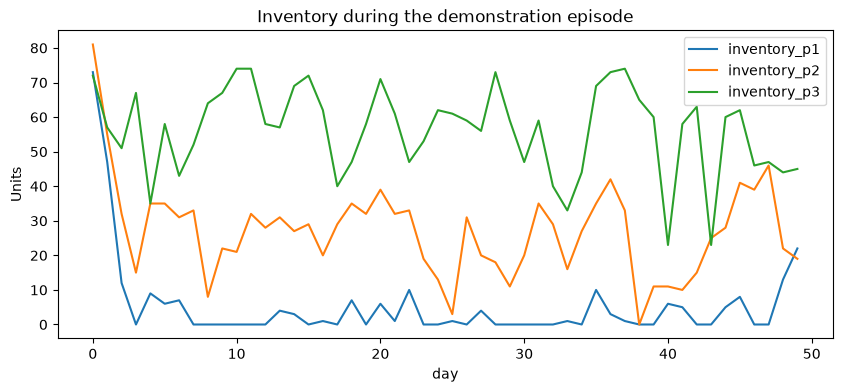

In [13]:
one_episode_results.plot(
    x="day",
    y=["inventory_p1", "inventory_p2", "inventory_p3"],
    figsize=(10, 4),
    title="Inventory during the demonstration episode",
)
plt.ylabel("Units")
plt.show()

In [14]:
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"

for directory in [
    RESULTS_DIR,
    MODELS_DIR,
    CHECKPOINTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

baseline_file = RESULTS_DIR / "demonstration_seed101.csv"

one_episode_results.to_csv(
    baseline_file,
    index=False,
)

print("Baseline result saved:", baseline_file)
print("File exists:", baseline_file.exists())

Baseline result saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\demonstration_seed101.csv
File exists: True


## 8. Build the local evaluation loop

Create a function that evaluates a supplied policy across multiple disclosed validation seeds and multiple declared scenario families. At minimum, record:

- average and standard deviation of total episode cost;
- holding, stockout, ordering and discarding costs;
- service level or unfulfilled demand;
- computational time;
- the seeds and scenario modes used.

Do not tune against one favourable seed. Keep the final public and private leaderboard episodes hidden and evaluator-controlled.

In [15]:
import time
import numpy as np
import pandas as pd


def validate_order_quantities(quantities):
    """
    Validate quantities returned by a policy.

    A submitted policy must return exactly three integer quantities,
    and every quantity must be one of 0, 10, ..., 100.
    """
    quantities = np.asarray(quantities)

    if quantities.shape != (3,):
        raise ValueError(
            "Policy must return exactly three order quantities."
        )

    if not np.all(np.isfinite(quantities)):
        raise ValueError("Policy returned a non-finite quantity.")

    if not np.all(quantities == np.round(quantities)):
        raise ValueError("Policy quantities must be integers.")

    quantities = quantities.astype(np.int64)

    valid = (
        (quantities >= 0)
        & (quantities <= 100)
        & (quantities % 10 == 0)
    )

    if not np.all(valid):
        raise ValueError(
            "Each quantity must be one of 0, 10, ..., 100."
        )

    return quantities.tolist()


def evaluate_policy(
    policy,
    student_config,
    seeds,
    scenario_modes,
    policy_name="Policy",
):
    """
    Evaluate a deterministic policy using common seeds and scenarios.

    Returns one row per completed 50-day episode.
    """
    episode_records = []

    for scenario_mode in scenario_modes:
        for seed in seeds:
            evaluation_env = IndustrialInventoryEnv(
                student_config=student_config,
                scenario_mode=scenario_mode,
                domain_randomization=True,
            )

            observation, reset_info = evaluation_env.reset(
                seed=int(seed)
            )

            holding_cost = 0.0
            stockout_cost = 0.0
            ordering_cost = 0.0
            discarding_cost = 0.0

            total_demand = np.zeros(3, dtype=np.int64)
            total_fulfilled = np.zeros(3, dtype=np.int64)
            total_unfulfilled = np.zeros(3, dtype=np.int64)
            total_orders = np.zeros(3, dtype=np.int64)

            nonzero_order_days = np.zeros(3, dtype=np.int64)
            discard_events = 0
            stockout_days = 0
            inference_times = []

            days = 0
            final_info = None

            while True:
                start_time = time.perf_counter()

                quantities = policy(observation)
                quantities = validate_order_quantities(quantities)

                elapsed = time.perf_counter() - start_time
                inference_times.append(elapsed)

                action_indices = (
                    evaluation_env.quantities_to_action_indices(
                        quantities
                    )
                )

                (
                    next_observation,
                    reward,
                    terminated,
                    truncated,
                    step_info,
                ) = evaluation_env.step(action_indices)

                costs = step_info["costs"]

                holding_cost += float(costs["holding"])
                stockout_cost += float(costs["stockout"])
                ordering_cost += float(costs["ordering"])
                discarding_cost += float(costs["discarding"])

                demand = np.asarray(
                    step_info["demand"],
                    dtype=np.int64,
                )
                fulfilled = np.asarray(
                    step_info["fulfilled_demand"],
                    dtype=np.int64,
                )
                unfulfilled = np.asarray(
                    step_info["unfulfilled_demand"],
                    dtype=np.int64,
                )
                discarded = np.asarray(
                    step_info["discarded_units"],
                    dtype=np.int64,
                )
                quantities_array = np.asarray(
                    quantities,
                    dtype=np.int64,
                )

                total_demand += demand
                total_fulfilled += fulfilled
                total_unfulfilled += unfulfilled
                total_orders += quantities_array

                nonzero_order_days += (
                    quantities_array > 0
                ).astype(np.int64)

                if unfulfilled.sum() > 0:
                    stockout_days += 1

                if discarded.sum() > 0:
                    discard_events += 1

                observation = next_observation
                final_info = step_info
                days += 1

                if terminated or truncated:
                    break

            total_cost = (
                holding_cost
                + stockout_cost
                + ordering_cost
                + discarding_cost
            )

            demand_units = int(total_demand.sum())
            fulfilled_units = int(total_fulfilled.sum())

            if demand_units > 0:
                service_level = fulfilled_units / demand_units
            else:
                service_level = 1.0

            episode_records.append(
                {
                    "policy": policy_name,
                    "scenario": str(scenario_mode),
                    "seed": int(seed),
                    "days": days,
                    "total_cost": total_cost,
                    "holding_cost": holding_cost,
                    "stockout_cost": stockout_cost,
                    "ordering_cost": ordering_cost,
                    "discarding_cost": discarding_cost,
                    "demand_units": demand_units,
                    "fulfilled_units": fulfilled_units,
                    "unfulfilled_units": int(
                        total_unfulfilled.sum()
                    ),
                    "service_level": service_level,
                    "stockout_days": stockout_days,
                    "discard_events": discard_events,
                    "total_order_p1": int(total_orders[0]),
                    "total_order_p2": int(total_orders[1]),
                    "total_order_p3": int(total_orders[2]),
                    "nonzero_order_days_p1": int(
                        nonzero_order_days[0]
                    ),
                    "nonzero_order_days_p2": int(
                        nonzero_order_days[1]
                    ),
                    "nonzero_order_days_p3": int(
                        nonzero_order_days[2]
                    ),
                    "mean_inference_seconds": float(
                        np.mean(inference_times)
                    ),
                    "variant_id": reset_info["variant_id"],
                    "config_fingerprint": (
                        student_config["config_fingerprint"]
                    ),
                    "final_episode_cost": float(
                        final_info["costs"]["episode_total"]
                    ),
                }
            )

    results = pd.DataFrame(episode_records)

    if not np.all(results["days"] == 50):
        raise RuntimeError(
            "One or more evaluation episodes did not complete 50 days."
        )

    if not np.allclose(
        results["total_cost"],
        results["final_episode_cost"],
    ):
        raise RuntimeError(
            "Calculated costs do not match environment episode costs."
        )

    return results

In [16]:
VALIDATION_SEEDS = [
    1001,
    1002,
    1003,
    1004,
    1005,
]

VALIDATION_SCENARIOS = [
    "stationary",
    "seasonal",
    "trend",
    "shock",
    "mixed",
]

print("Validation seeds:", VALIDATION_SEEDS)
print("Validation scenarios:", VALIDATION_SCENARIOS)
print(
    "Total validation episodes:",
    len(VALIDATION_SEEDS) * len(VALIDATION_SCENARIOS),
)

Validation seeds: [1001, 1002, 1003, 1004, 1005]
Validation scenarios: ['stationary', 'seasonal', 'trend', 'shock', 'mixed']
Total validation episodes: 25


In [17]:
TRAINING_SEEDS = list(range(1, 1001))

assert set(TRAINING_SEEDS).isdisjoint(VALIDATION_SEEDS)
print("Training/validation seed separation: PASS")

Training/validation seed separation: PASS


In [18]:
baseline_validation_results = evaluate_policy(
    policy=demonstration_policy,
    student_config=student_config,
    seeds=VALIDATION_SEEDS,
    scenario_modes=VALIDATION_SCENARIOS,
    policy_name="Demonstration Baseline",
)

print("Evaluation completed.")
print(
    "Episodes:",
    len(baseline_validation_results),
)

display(baseline_validation_results.head())

Evaluation completed.
Episodes: 25


,policy,scenario,seed,days,total_cost,holding_cost,stockout_cost,ordering_cost,discarding_cost,demand_units,...,total_order_p1,total_order_p2,total_order_p3,nonzero_order_days_p1,nonzero_order_days_p2,nonzero_order_days_p3,mean_inference_seconds,variant_id,config_fingerprint,final_episode_cost
0,Demonstration Baseline,stationary,1001,50,207120.0,46920.0,140800.0,19400.0,0.0,4575,...,1340,1200,1640,45,49,50,0.000049,V024,db750dbfac3be81f,207120.0
1,Demonstration Baseline,stationary,1002,50,181392.5,45272.5,116600.0,19520.0,0.0,4527,...,1340,1190,1650,49,48,50,0.000051,V024,db750dbfac3be81f,181392.5
2,Demonstration Baseline,stationary,1003,50,185862.5,53262.5,113200.0,19400.0,0.0,4265,...,1280,1120,1550,45,49,50,0.000038,V024,db750dbfac3be81f,185862.5
3,Demonstration Baseline,stationary,1004,50,220407.5,49127.5,151800.0,19480.0,0.0,4466,...,1340,1180,1560,46,49,50,0.000037,V024,db750dbfac3be81f,220407.5
4,Demonstration Baseline,stationary,1005,50,181450.0,48210.0,113600.0,19640.0,0.0,4508,...,1350,1130,1700,48,49,50,0.000042,V024,db750dbfac3be81f,181450.0


In [19]:
baseline_summary = (
    baseline_validation_results
    .groupby("policy")
    .agg(
        episodes=("total_cost", "count"),
        average_cost=("total_cost", "mean"),
        standard_deviation=("total_cost", "std"),
        median_cost=("total_cost", "median"),
        minimum_cost=("total_cost", "min"),
        maximum_cost=("total_cost", "max"),
        average_holding_cost=("holding_cost", "mean"),
        average_stockout_cost=("stockout_cost", "mean"),
        average_ordering_cost=("ordering_cost", "mean"),
        average_discarding_cost=("discarding_cost", "mean"),
        average_service_level=("service_level", "mean"),
        average_stockout_days=("stockout_days", "mean"),
        average_discard_events=("discard_events", "mean"),
        mean_inference_seconds=(
            "mean_inference_seconds",
            "mean",
        ),
    )
    .reset_index()
)

display(baseline_summary)

,policy,episodes,average_cost,standard_deviation,median_cost,minimum_cost,maximum_cost,average_holding_cost,average_stockout_cost,average_ordering_cost,average_discarding_cost,average_service_level,average_stockout_days,average_discard_events,mean_inference_seconds
0,Demonstration Baseline,25,194325.7,24308.952553,185550.0,159752.5,245840.0,47992.1,126740.0,19593.6,0.0,0.92982,29.24,0.0,0.000047


In [20]:
baseline_scenario_summary = (
    baseline_validation_results
    .groupby("scenario")
    .agg(
        episodes=("total_cost", "count"),
        average_cost=("total_cost", "mean"),
        cost_std=("total_cost", "std"),
        average_stockout_cost=("stockout_cost", "mean"),
        average_holding_cost=("holding_cost", "mean"),
        average_ordering_cost=("ordering_cost", "mean"),
        average_discarding_cost=("discarding_cost", "mean"),
        average_service_level=("service_level", "mean"),
        average_stockout_days=("stockout_days", "mean"),
    )
    .reset_index()
    .sort_values("average_cost")
)

display(baseline_scenario_summary)

,scenario,episodes,average_cost,cost_std,average_stockout_cost,average_holding_cost,average_ordering_cost,average_discarding_cost,average_service_level,average_stockout_days
2,shock,5,190873.0,29458.981037,124520.0,46825.0,19528.0,0.0,0.931438,28.8
1,seasonal,5,191133.0,19351.664770,123000.0,48517.0,19616.0,0.0,0.931466,28.4
3,stationary,5,195246.5,17637.971167,127200.0,48558.5,19488.0,0.0,0.929090,28.8
4,trend,5,196458.0,35152.339378,127660.0,49126.0,19672.0,0.0,0.928798,30.4
0,mixed,5,197918.0,26569.352257,131320.0,46934.0,19664.0,0.0,0.928305,29.8


In [21]:
assert len(baseline_validation_results) == 25
assert baseline_validation_results["days"].eq(50).all()

assert np.allclose(
    baseline_validation_results["total_cost"],
    baseline_validation_results[
        [
            "holding_cost",
            "stockout_cost",
            "ordering_cost",
            "discarding_cost",
        ]
    ].sum(axis=1),
)

assert (
    baseline_validation_results["variant_id"]
    == "V024"
).all()

assert (
    baseline_validation_results["config_fingerprint"]
    == "db750dbfac3be81f"
).all()

assert baseline_validation_results[
    "service_level"
].between(0.0, 1.0).all()

print("Baseline evaluation consistency checks: PASS")

Baseline evaluation consistency checks: PASS


In [22]:
PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

baseline_results_file = (
    RESULTS_DIR
    / "baseline_validation_episode_results.csv"
)

baseline_summary_file = (
    RESULTS_DIR
    / "baseline_validation_summary.csv"
)

baseline_scenario_file = (
    RESULTS_DIR
    / "baseline_validation_scenario_summary.csv"
)

baseline_validation_results.to_csv(
    baseline_results_file,
    index=False,
)

baseline_summary.to_csv(
    baseline_summary_file,
    index=False,
)

baseline_scenario_summary.to_csv(
    baseline_scenario_file,
    index=False,
)

print("Saved:", baseline_results_file)
print("Saved:", baseline_summary_file)
print("Saved:", baseline_scenario_file)

Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\baseline_validation_episode_results.csv
Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\baseline_validation_summary.csv
Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\baseline_validation_scenario_summary.csv


In [23]:
assert baseline_results_file.exists()
assert baseline_summary_file.exists()
assert baseline_scenario_file.exists()

saved_episode_results = pd.read_csv(
    baseline_results_file
)

assert len(saved_episode_results) == 25

print("Saved baseline files: PASS")

Saved baseline files: PASS


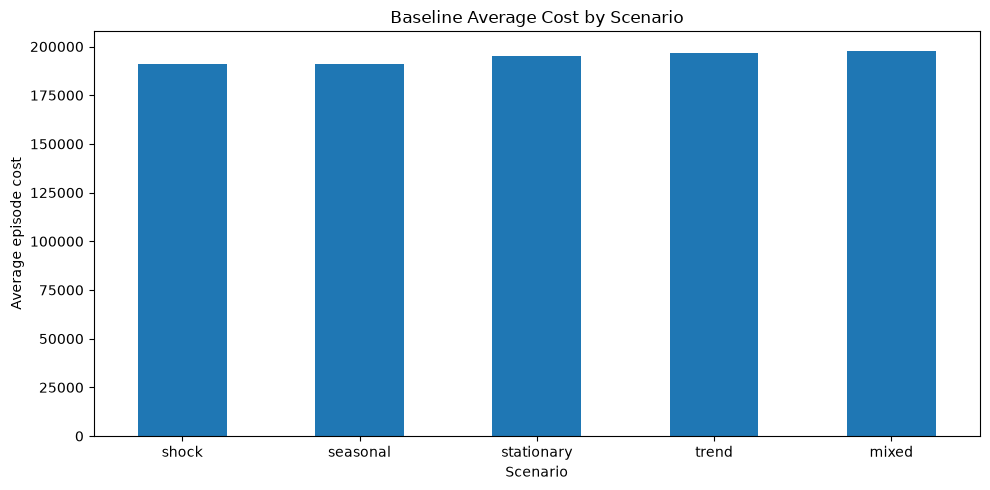

In [24]:
plot_data = (
    baseline_scenario_summary
    .sort_values("average_cost")
)

ax = plot_data.plot(
    x="scenario",
    y="average_cost",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Baseline Average Cost by Scenario",
)

ax.set_xlabel("Scenario")
ax.set_ylabel("Average episode cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

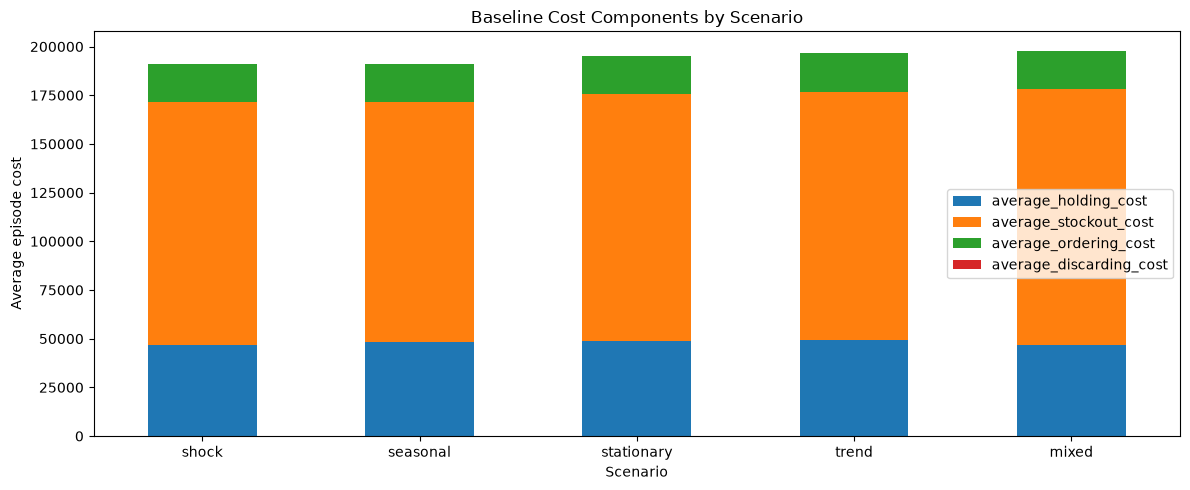

In [25]:
component_columns = [
    "average_holding_cost",
    "average_stockout_cost",
    "average_ordering_cost",
    "average_discarding_cost",
]

ax = baseline_scenario_summary.plot(
    x="scenario",
    y=component_columns,
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    title="Baseline Cost Components by Scenario",
)

ax.set_xlabel("Scenario")
ax.set_ylabel("Average episode cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Submission checks

For every policy file:

```bash
python policy_validation_tests.py path/to/policy_file.py
```

The final notebook must reproduce the training/export process and clearly map each frozen leaderboard submission to its technique, policy file and model artefact. The brief report should focus on what was implemented, what results were obtained and what was inferred.

In [26]:
# Global final-run controls
PYTHON_REQUIRED = "3.14"
TARGET_AVERAGE_COST = 90000.0
FINAL_VALIDATION_SEEDS = [1001, 1002, 1003, 1004, 1005]
FINAL_VALIDATION_SCENARIOS = ["stationary", "seasonal", "trend", "shock", "mixed"]

# Final budgets. These values prioritize learning quality over short runtime.
FINAL_BUDGETS = {
    "tabular_q_learning_episodes": 8000,
    "tabular_sarsa_episodes": 8000,
    "sarsa_lambda_episodes": 6000,
    "dqn_episodes": 3000,
    "double_dqn_episodes": 3500,
    "ppo_episodes": 2500,
    "reinforce_episodes": 3000,
    "neural_q_learning_episodes": 3000,
    "neural_sarsa_episodes": 3000,
    "a2c_episodes": 2500,
    "a3c_episodes": 2500,
}

print("Python target:", PYTHON_REQUIRED)
print("Held-out target cost:", TARGET_AVERAGE_COST)
print("Validation episodes:", len(FINAL_VALIDATION_SEEDS) * len(FINAL_VALIDATION_SCENARIOS))
display(pd.DataFrame([FINAL_BUDGETS]).T.rename(columns={0: "budget"}))


Python target: 3.14
Held-out target cost: 90000.0
Validation episodes: 25


,budget
tabular_q_learning_episodes,8000
tabular_sarsa_episodes,8000
sarsa_lambda_episodes,6000
dqn_episodes,3000
double_dqn_episodes,3500
ppo_episodes,2500
reinforce_episodes,3000
neural_q_learning_episodes,3000
neural_sarsa_episodes,3000
a2c_episodes,2500


## Final notebook structure

For each technique I recorded the observation processing, action representation, training reward, main hyperparameters, learning evidence and held-out validation result. The final comparison uses the same five scenario families and validation seeds for every completed policy. Policy files are written only inside technique-specific folders under `leaderboard`, then packaged into separate ZIP files.


## 11. Technique 1: Tabular Q-Learning

Tabular Q-Learning was implemented using a compact discretized state representation. The state uses inventory position relative to recent demand, warehouse capacity utilisation, and episode progress. Exploration is epsilon-greedy during training, while validation and submission inference use deterministic greedy action selection.

In [27]:
from collections import defaultdict
import random
import time

Q_LEARNING_RANDOM_SEED = 543
random.seed(Q_LEARNING_RANDOM_SEED)
np.random.seed(Q_LEARNING_RANDOM_SEED)

TABULAR_ACTION_LEVELS = np.asarray(
    [0, 20, 40, 60, 80, 100],
    dtype=np.int64,
)

TABULAR_ACTIONS = np.asarray(
    [
        [product_1, product_2, product_3]
        for product_1 in TABULAR_ACTION_LEVELS
        for product_2 in TABULAR_ACTION_LEVELS
        for product_3 in TABULAR_ACTION_LEVELS
    ],
    dtype=np.int64,
)

if TABULAR_ACTIONS.shape != (216, 3):
    raise RuntimeError(
        f"Expected a 216 x 3 tabular action array, received {TABULAR_ACTIONS.shape}."
    )
if len(np.unique(TABULAR_ACTIONS, axis=0)) != 216:
    raise RuntimeError("The 216-action tabular action array contains duplicates.")
if not np.all((TABULAR_ACTIONS >= 0) & (TABULAR_ACTIONS <= 100)):
    raise RuntimeError("A tabular order quantity is outside 0 to 100.")
if not np.all(TABULAR_ACTIONS % 10 == 0):
    raise RuntimeError("A tabular order quantity is not a multiple of 10.")

print("Tabular quantity levels:", TABULAR_ACTION_LEVELS.tolist())
print("Number of independent joint tabular actions:", len(TABULAR_ACTIONS))
print("216-action tabular action-space validation: PASS")
display(pd.DataFrame(TABULAR_ACTIONS, columns=["Product 1", "Product 2", "Product 3"]).head(20))


Tabular quantity levels: [0, 20, 40, 60, 80, 100]
Number of independent joint tabular actions: 216
216-action tabular action-space validation: PASS


,Product 1,Product 2,Product 3
0,0,0,0
1,0,0,20
2,0,0,40
3,0,0,60
4,0,0,80
5,0,0,100
6,0,20,0
7,0,20,20
8,0,20,40
9,0,20,60


In [28]:
def recent_mean_demand(observation):
    """
    Estimate recent demand while ignoring zero-padded history rows.
    """
    history = np.asarray(
        observation["demand_history"],
        dtype=np.float64,
    )

    observed_rows = history[np.any(history > 0, axis=1)]

    if len(observed_rows) == 0:
        return np.asarray(
            [33.0, 25.0, 31.5],
            dtype=np.float64,
        )

    return observed_rows.mean(axis=0)


def discretize_ratio(value):
    """
    Convert an inventory-coverage ratio into one of five categories.
    """
    if value < 0.75:
        return 0
    if value < 1.25:
        return 1
    if value < 1.75:
        return 2
    if value < 2.50:
        return 3
    return 4


def tabular_state(observation):
    """
    Construct a compact state for tabular learning.

    Inventory position includes on-hand inventory and all outstanding
    orders. It is normalized by estimated lead-time demand.
    """
    inventory = np.asarray(
        observation["inventory"],
        dtype=np.float64,
    )

    pipeline = np.asarray(
        observation["arrival_pipeline"],
        dtype=np.float64,
    )

    demand_mean = recent_mean_demand(observation)
    inventory_position = inventory + pipeline.sum(axis=1)

    reference_lead_times = np.asarray(
        [3.0, 2.0, 1.0],
        dtype=np.float64,
    )

    expected_lead_time_demand = np.maximum(
        demand_mean * reference_lead_times,
        1.0,
    )

    coverage_ratio = (
        inventory_position / expected_lead_time_demand
    )

    coverage_bins = tuple(
        discretize_ratio(value)
        for value in coverage_ratio
    )

    capacity_utilisation = float(
        np.asarray(
            observation["capacity_utilisation"]
        ).reshape(-1)[0]
    )

    if capacity_utilisation < 0.40:
        capacity_bin = 0
    elif capacity_utilisation < 0.70:
        capacity_bin = 1
    elif capacity_utilisation < 0.90:
        capacity_bin = 2
    else:
        capacity_bin = 3

    day = int(
        np.asarray(
            observation["day"]
        ).reshape(-1)[0]
    )

    day_bin = min(day // 10, 4)

    return coverage_bins + (
        capacity_bin,
        day_bin,
    )

In [29]:
test_state = tabular_state(observation)

print("Example tabular state:", test_state)
print("State length:", len(test_state))

assert isinstance(test_state, tuple)
assert len(test_state) == 5
assert all(isinstance(value, int) for value in test_state)

print("Tabular state preprocessing: PASS")

Example tabular state: (1, 2, 3, 0, 4)
State length: 5
Tabular state preprocessing: PASS


In [30]:
def make_q_table(number_of_actions):
    """
    Create a Q-table whose unseen states begin with zero values.
    """
    return defaultdict(
        lambda: np.zeros(
            number_of_actions,
            dtype=np.float64,
        )
    )


def choose_q_learning_action(
    q_table,
    state,
    epsilon,
    rng,
):
    """
    Select an epsilon-greedy action index.
    """
    if rng.random() < epsilon:
        return int(
            rng.integers(len(TABULAR_ACTIONS))
        )

    q_values = q_table[state]
    maximum_value = np.max(q_values)

    best_actions = np.flatnonzero(
        np.isclose(q_values, maximum_value)
    )

    return int(rng.choice(best_actions))

In [31]:
Q_LEARNING_TEST_EPISODES = 20

Q_LEARNING_EPISODES = FINAL_BUDGETS["tabular_q_learning_episodes"]
Q_LEARNING_ALPHA = 0.05
Q_LEARNING_GAMMA = 0.99
Q_LEARNING_EPSILON_START = 1.00
Q_LEARNING_EPSILON_END = 0.02
Q_LEARNING_EPSILON_DECAY = 0.9992

print("Q-Learning hyperparameters")
print("Test episodes:", Q_LEARNING_TEST_EPISODES)
print("Full episodes:", Q_LEARNING_EPISODES)
print("Alpha:", Q_LEARNING_ALPHA)
print("Gamma:", Q_LEARNING_GAMMA)
print("Initial epsilon:", Q_LEARNING_EPSILON_START)
print("Final epsilon:", Q_LEARNING_EPSILON_END)
print("Epsilon decay:", Q_LEARNING_EPSILON_DECAY)

Q-Learning hyperparameters
Test episodes: 20
Full episodes: 8000
Alpha: 0.05
Gamma: 0.99
Initial epsilon: 1.0
Final epsilon: 0.02
Epsilon decay: 0.9992


In [32]:
def train_q_learning(
    student_config,
    episodes,
    alpha=0.10,
    gamma=0.99,
    epsilon_start=1.00,
    epsilon_end=0.05,
    epsilon_decay=0.9985,
    random_seed=543,
    progress_interval=100,
):
    """
    Train a tabular Q-Learning policy.
    """
    rng = np.random.default_rng(random_seed)

    q_table = make_q_table(
        len(TABULAR_ACTIONS)
    )

    training_records = []
    epsilon = float(epsilon_start)
    start_time = time.perf_counter()

    for episode in range(1, episodes + 1):
        training_env = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True,
        )

        environment_seed = int(
            rng.integers(1, 1_000_000_000)
        )

        observation, reset_info = training_env.reset(
            seed=environment_seed
        )

        state = tabular_state(observation)

        episode_reward = 0.0
        episode_cost = 0.0
        episode_stockout_cost = 0.0
        episode_holding_cost = 0.0
        episode_ordering_cost = 0.0
        episode_discarding_cost = 0.0
        steps = 0

        while True:
            action_index = choose_q_learning_action(
                q_table=q_table,
                state=state,
                epsilon=epsilon,
                rng=rng,
            )

            order_quantities = TABULAR_ACTIONS[
                action_index
            ]

            internal_action = (
                training_env
                .quantities_to_action_indices(
                    order_quantities
                )
            )

            (
                next_observation,
                reward,
                terminated,
                truncated,
                step_info,
            ) = training_env.step(internal_action)

            next_state = tabular_state(
                next_observation
            )

            episode_finished = (
                terminated or truncated
            )

            if episode_finished:
                next_maximum = 0.0
            else:
                next_maximum = float(
                    np.max(q_table[next_state])
                )

            old_value = q_table[state][
                action_index
            ]

            target = (
                float(reward)
                + gamma * next_maximum
            )

            q_table[state][action_index] = (
                old_value
                + alpha * (target - old_value)
            )

            costs = step_info["costs"]

            episode_reward += float(reward)
            episode_cost += float(
                costs["daily_total"]
            )
            episode_holding_cost += float(
                costs["holding"]
            )
            episode_stockout_cost += float(
                costs["stockout"]
            )
            episode_ordering_cost += float(
                costs["ordering"]
            )
            episode_discarding_cost += float(
                costs["discarding"]
            )

            observation = next_observation
            state = next_state
            steps += 1

            if episode_finished:
                break

        training_records.append(
            {
                "episode": episode,
                "environment_seed": (
                    environment_seed
                ),
                "epsilon": epsilon,
                "episode_reward": (
                    episode_reward
                ),
                "episode_cost": episode_cost,
                "holding_cost": (
                    episode_holding_cost
                ),
                "stockout_cost": (
                    episode_stockout_cost
                ),
                "ordering_cost": (
                    episode_ordering_cost
                ),
                "discarding_cost": (
                    episode_discarding_cost
                ),
                "steps": steps,
                "states_seen": len(q_table),
            }
        )

        epsilon = max(
            epsilon_end,
            epsilon * epsilon_decay,
        )

        if (
            episode == 1
            or episode % progress_interval == 0
            or episode == episodes
        ):
            recent_costs = [
                row["episode_cost"]
                for row in training_records[-100:]
            ]

            print(
                f"Episode {episode:5d}/{episodes}, "
                f"epsilon={epsilon:.4f}, "
                f"recent_mean_cost="
                f"{np.mean(recent_costs):.2f}, "
                f"states={len(q_table)}"
            )

    elapsed_time = (
        time.perf_counter() - start_time
    )

    training_results = pd.DataFrame(
        training_records
    )

    return (
        q_table,
        training_results,
        elapsed_time,
    )

In [33]:
(
    q_table_test,
    q_learning_test_results,
    q_learning_test_seconds,
) = train_q_learning(
    student_config=student_config,
    episodes=Q_LEARNING_TEST_EPISODES,
    alpha=Q_LEARNING_ALPHA,
    gamma=Q_LEARNING_GAMMA,
    epsilon_start=Q_LEARNING_EPSILON_START,
    epsilon_end=Q_LEARNING_EPSILON_END,
    epsilon_decay=Q_LEARNING_EPSILON_DECAY,
    random_seed=Q_LEARNING_RANDOM_SEED,
    progress_interval=5,
)

print("\nSmoke test completed.")
print("Episodes:", len(q_learning_test_results))
print("States visited:", len(q_table_test))
print("Elapsed seconds:", q_learning_test_seconds)

assert len(q_learning_test_results) == 20
assert q_learning_test_results["steps"].eq(50).all()
assert len(q_table_test) > 0
assert np.isfinite(
    q_learning_test_results["episode_cost"]
).all()

print("Q-Learning smoke test: PASS")

Episode     1/20, epsilon=0.9992, recent_mean_cost=1118342.50, states=30
Episode     5/20, epsilon=0.9960, recent_mean_cost=1050814.50, states=82
Episode    10/20, epsilon=0.9920, recent_mean_cost=999690.75, states=122
Episode    15/20, epsilon=0.9881, recent_mean_cost=989760.00, states=145
Episode    20/20, epsilon=0.9841, recent_mean_cost=983757.62, states=161

Smoke test completed.
Episodes: 20
States visited: 161
Elapsed seconds: 0.2031870000064373
Q-Learning smoke test: PASS


In [34]:
(
    q_learning_table,
    q_learning_training_results,
    q_learning_training_seconds,
) = train_q_learning(
    student_config=student_config,
    episodes=Q_LEARNING_EPISODES,
    alpha=Q_LEARNING_ALPHA,
    gamma=Q_LEARNING_GAMMA,
    epsilon_start=Q_LEARNING_EPSILON_START,
    epsilon_end=Q_LEARNING_EPSILON_END,
    epsilon_decay=Q_LEARNING_EPSILON_DECAY,
    random_seed=Q_LEARNING_RANDOM_SEED,
    progress_interval=100,
)

print("\nFull Q-Learning training completed.")
print(
    "Training episodes:",
    len(q_learning_training_results),
)
print(
    "Visited states:",
    len(q_learning_table),
)
print(
    "Training time in seconds:",
    q_learning_training_seconds,
)
print(
    "Last 100 episode average cost:",
    q_learning_training_results[
        "episode_cost"
    ].tail(100).mean(),
)

Episode     1/8000, epsilon=0.9992, recent_mean_cost=1118342.50, states=30
Episode   100/8000, epsilon=0.9231, recent_mean_cost=936573.35, states=315
Episode   200/8000, epsilon=0.8521, recent_mean_cost=912189.28, states=393
Episode   300/8000, epsilon=0.7866, recent_mean_cost=925602.38, states=434
Episode   400/8000, epsilon=0.7261, recent_mean_cost=883071.18, states=485
Episode   500/8000, epsilon=0.6702, recent_mean_cost=899027.28, states=513
Episode   600/8000, epsilon=0.6187, recent_mean_cost=910506.53, states=536
Episode   700/8000, epsilon=0.5711, recent_mean_cost=931338.88, states=555
Episode   800/8000, epsilon=0.5272, recent_mean_cost=916730.60, states=579
Episode   900/8000, epsilon=0.4866, recent_mean_cost=875196.25, states=590
Episode  1000/8000, epsilon=0.4492, recent_mean_cost=915705.75, states=601
Episode  1100/8000, epsilon=0.4146, recent_mean_cost=929811.70, states=620
Episode  1200/8000, epsilon=0.3827, recent_mean_cost=919260.60, states=624
Episode  1300/8000, epsil

In [35]:
Q_LEARNING_RESULTS_FILE = (
    RESULTS_DIR
    / "q_learning_training_results.csv"
)

q_learning_training_results.to_csv(
    Q_LEARNING_RESULTS_FILE,
    index=False,
)

print("Saved:", Q_LEARNING_RESULTS_FILE)

Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\q_learning_training_results.csv


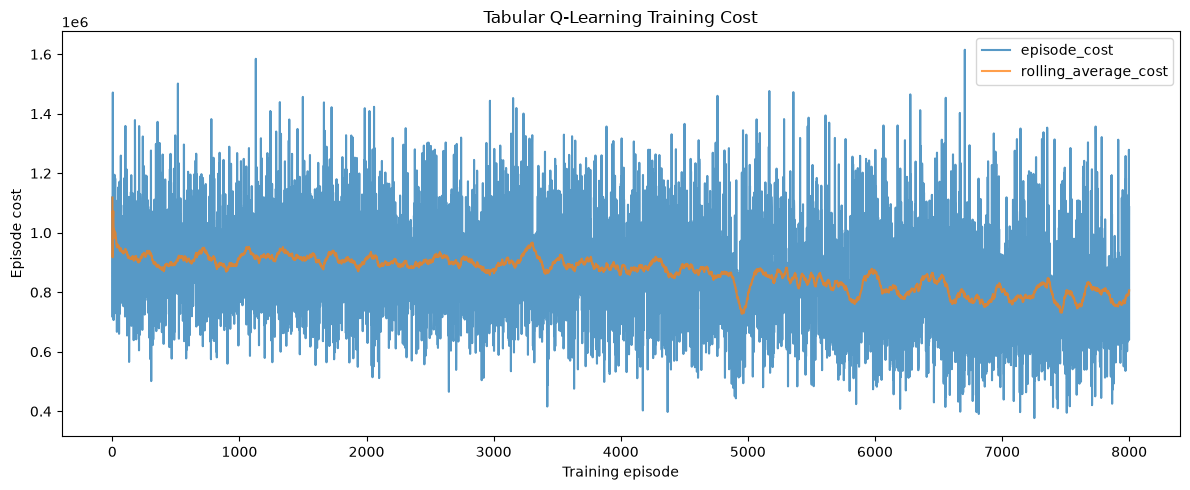

In [36]:
q_learning_plot_data = (
    q_learning_training_results.copy()
)

q_learning_plot_data[
    "rolling_average_cost"
] = (
    q_learning_plot_data["episode_cost"]
    .rolling(window=100, min_periods=1)
    .mean()
)

ax = q_learning_plot_data.plot(
    x="episode",
    y=[
        "episode_cost",
        "rolling_average_cost",
    ],
    figsize=(12, 5),
    alpha=0.75,
    title="Tabular Q-Learning Training Cost",
)

ax.set_xlabel("Training episode")
ax.set_ylabel("Episode cost")
plt.tight_layout()
plt.show()

In [37]:
print("Q-Learning training verification")
print("--------------------------------")
print("Training episodes:", len(q_learning_training_results))
print("Visited states:", len(q_learning_table))
print("Training seconds:", q_learning_training_seconds)
print(
    "First 100 average cost:",
    q_learning_training_results["episode_cost"].head(100).mean(),
)
print(
    "Last 100 average cost:",
    q_learning_training_results["episode_cost"].tail(100).mean(),
)
print(
    "Final epsilon:",
    q_learning_training_results["epsilon"].iloc[-1],
)

assert len(q_learning_training_results) == Q_LEARNING_EPISODES
assert q_learning_training_results["steps"].eq(50).all()
assert len(q_learning_table) > 0
assert np.isfinite(
    q_learning_training_results["episode_cost"]
).all()

print("\nFull Q-Learning training verification: PASS")

Q-Learning training verification
--------------------------------
Training episodes: 8000
Visited states: 989
Training seconds: 92.29914050002117
First 100 average cost: 936573.35
Last 100 average cost: 806354.525
Final epsilon: 0.02

Full Q-Learning training verification: PASS


In [38]:
def q_learning_policy(observation):
    """
    Return deterministic order quantities from the trained Q-table.

    If the current discretized state was not encountered during
    training, use the demonstration policy as a safe fallback.
    """
    state = tabular_state(observation)

    if state not in q_learning_table:
        return demonstration_policy(observation)

    q_values = np.asarray(
        q_learning_table[state],
        dtype=np.float64,
    )

    best_action_index = int(np.argmax(q_values))

    order_quantities = TABULAR_ACTIONS[
        best_action_index
    ]

    return order_quantities.astype(int).tolist()

In [39]:
test_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)

test_observation, test_info = test_env.reset(seed=2001)

first_action = q_learning_policy(test_observation)
second_action = q_learning_policy(test_observation)

print("First action:", first_action)
print("Second action:", second_action)

first_action = validate_order_quantities(first_action)
second_action = validate_order_quantities(second_action)

assert first_action == second_action
assert len(first_action) == 3
assert all(
    quantity in range(0, 101, 10)
    for quantity in first_action
)

print("Q-Learning deterministic inference: PASS")

First action: [60, 0, 0]
Second action: [60, 0, 0]
Q-Learning deterministic inference: PASS


### Q-Learning validation

The trained Q-Learning policy is now evaluated deterministically using the same
held-out seeds and scenario families used for the demonstration baseline.

Using identical validation episodes allows the Q-Learning policy to be compared
fairly with the baseline in terms of total episode cost, cost components,
service level, stockout frequency, and inference time.

In [40]:
q_learning_validation_results = evaluate_policy(
    policy=q_learning_policy,
    student_config=student_config,
    seeds=VALIDATION_SEEDS,
    scenario_modes=VALIDATION_SCENARIOS,
    policy_name="Tabular Q-Learning",
)

print("Q-Learning evaluation completed.")
print(
    "Validation episodes:",
    len(q_learning_validation_results),
)

display(q_learning_validation_results.head())

Q-Learning evaluation completed.
Validation episodes: 25


,policy,scenario,seed,days,total_cost,holding_cost,stockout_cost,ordering_cost,discarding_cost,demand_units,...,total_order_p1,total_order_p2,total_order_p3,nonzero_order_days_p1,nonzero_order_days_p2,nonzero_order_days_p3,mean_inference_seconds,variant_id,config_fingerprint,final_episode_cost
0,Tabular Q-Learning,stationary,1001,50,327725.0,50025.0,264500.0,13200.0,0.0,4575,...,1250,1140,1460,30,33,35,0.000189,V024,db750dbfac3be81f,327725.0
1,Tabular Q-Learning,stationary,1002,50,311922.5,46602.5,251600.0,13720.0,0.0,4527,...,1080,1170,1580,31,34,37,0.000176,V024,db750dbfac3be81f,311922.5
2,Tabular Q-Learning,stationary,1003,50,627105.0,138145.0,241500.0,11360.0,236100.0,4265,...,1890,1290,1600,32,26,30,0.000154,V024,db750dbfac3be81f,627105.0
3,Tabular Q-Learning,stationary,1004,50,500802.5,39402.5,449600.0,11800.0,0.0,4466,...,1090,940,1280,30,29,30,0.000112,V024,db750dbfac3be81f,500802.5
4,Tabular Q-Learning,stationary,1005,50,413195.0,77975.0,292500.0,13120.0,29600.0,4508,...,1100,1210,1500,31,34,32,0.000103,V024,db750dbfac3be81f,413195.0


In [41]:
assert len(q_learning_validation_results) == 25

assert q_learning_validation_results[
    "days"
].eq(50).all()

assert q_learning_validation_results[
    "total_cost"
].notna().all()

assert np.isfinite(
    q_learning_validation_results["total_cost"]
).all()

assert q_learning_validation_results[
    "service_level"
].between(0.0, 1.0).all()

calculated_q_learning_cost = (
    q_learning_validation_results["holding_cost"]
    + q_learning_validation_results["stockout_cost"]
    + q_learning_validation_results["ordering_cost"]
    + q_learning_validation_results["discarding_cost"]
)

assert np.allclose(
    q_learning_validation_results["total_cost"],
    calculated_q_learning_cost,
)

assert np.allclose(
    q_learning_validation_results["total_cost"],
    q_learning_validation_results["final_episode_cost"],
)

print("Q-Learning validation consistency checks: PASS")

Q-Learning validation consistency checks: PASS


In [42]:
q_learning_summary = (
    q_learning_validation_results
    .groupby("policy")
    .agg(
        episodes=("total_cost", "count"),
        average_cost=("total_cost", "mean"),
        standard_deviation=("total_cost", "std"),
        median_cost=("total_cost", "median"),
        minimum_cost=("total_cost", "min"),
        maximum_cost=("total_cost", "max"),
        average_holding_cost=(
            "holding_cost",
            "mean",
        ),
        average_stockout_cost=(
            "stockout_cost",
            "mean",
        ),
        average_ordering_cost=(
            "ordering_cost",
            "mean",
        ),
        average_discarding_cost=(
            "discarding_cost",
            "mean",
        ),
        average_service_level=(
            "service_level",
            "mean",
        ),
        average_stockout_days=(
            "stockout_days",
            "mean",
        ),
        average_discard_events=(
            "discard_events",
            "mean",
        ),
        mean_inference_seconds=(
            "mean_inference_seconds",
            "mean",
        ),
    )
    .reset_index()
)

display(q_learning_summary)

,policy,episodes,average_cost,standard_deviation,median_cost,minimum_cost,maximum_cost,average_holding_cost,average_stockout_cost,average_ordering_cost,average_discarding_cost,average_service_level,average_stockout_days,average_discard_events,mean_inference_seconds
0,Tabular Q-Learning,25,448707.6,68450.105823,462395.0,311922.5,627105.0,51553.6,364628.0,12544.0,19982.0,0.792616,29.08,1.32,0.000098


In [43]:
q_learning_comparison = pd.concat(
    [
        baseline_summary,
        q_learning_summary,
    ],
    ignore_index=True,
)

comparison_columns = [
    "policy",
    "episodes",
    "average_cost",
    "standard_deviation",
    "average_holding_cost",
    "average_stockout_cost",
    "average_ordering_cost",
    "average_discarding_cost",
    "average_service_level",
    "average_stockout_days",
    "mean_inference_seconds",
]

q_learning_comparison = (
    q_learning_comparison[
        comparison_columns
    ]
    .sort_values("average_cost")
    .reset_index(drop=True)
)

display(q_learning_comparison)

,policy,episodes,average_cost,standard_deviation,average_holding_cost,average_stockout_cost,average_ordering_cost,average_discarding_cost,average_service_level,average_stockout_days,mean_inference_seconds
0,Demonstration Baseline,25,194325.7,24308.952553,47992.1,126740.0,19593.6,0.0,0.929820,29.24,0.000047
1,Tabular Q-Learning,25,448707.6,68450.105823,51553.6,364628.0,12544.0,19982.0,0.792616,29.08,0.000098


In [44]:
baseline_average_cost = float(
    baseline_summary.loc[
        baseline_summary["policy"]
        == "Demonstration Baseline",
        "average_cost",
    ].iloc[0]
)

q_learning_average_cost = float(
    q_learning_summary.loc[
        q_learning_summary["policy"]
        == "Tabular Q-Learning",
        "average_cost",
    ].iloc[0]
)

q_learning_cost_improvement = (
    baseline_average_cost
    - q_learning_average_cost
)

q_learning_improvement_percentage = (
    q_learning_cost_improvement
    / baseline_average_cost
    * 100.0
)

print(
    "Baseline average cost:",
    baseline_average_cost,
)

print(
    "Q-Learning average cost:",
    q_learning_average_cost,
)

print(
    "Cost difference:",
    q_learning_cost_improvement,
)

print(
    "Improvement percentage:",
    f"{q_learning_improvement_percentage:.2f}%",
)

Baseline average cost: 194325.7
Q-Learning average cost: 448707.6
Cost difference: -254381.89999999997
Improvement percentage: -130.90%


In [45]:
Q_LEARNING_VALIDATION_FILE = (
    RESULTS_DIR
    / "q_learning_validation_episode_results.csv"
)

Q_LEARNING_SUMMARY_FILE = (
    RESULTS_DIR
    / "q_learning_validation_summary.csv"
)

Q_LEARNING_COMPARISON_FILE = (
    RESULTS_DIR
    / "baseline_q_learning_comparison.csv"
)

q_learning_validation_results.to_csv(
    Q_LEARNING_VALIDATION_FILE,
    index=False,
)

q_learning_summary.to_csv(
    Q_LEARNING_SUMMARY_FILE,
    index=False,
)

q_learning_comparison.to_csv(
    Q_LEARNING_COMPARISON_FILE,
    index=False,
)

print("Saved:", Q_LEARNING_VALIDATION_FILE)
print("Saved:", Q_LEARNING_SUMMARY_FILE)
print("Saved:", Q_LEARNING_COMPARISON_FILE)

Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\q_learning_validation_episode_results.csv
Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\q_learning_validation_summary.csv
Saved: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\results\baseline_q_learning_comparison.csv


In [46]:
assert Q_LEARNING_VALIDATION_FILE.exists()
assert Q_LEARNING_SUMMARY_FILE.exists()
assert Q_LEARNING_COMPARISON_FILE.exists()

saved_q_learning_results = pd.read_csv(
    Q_LEARNING_VALIDATION_FILE
)

assert len(saved_q_learning_results) == 25

print("Q-Learning validation files: PASS")

Q-Learning validation files: PASS


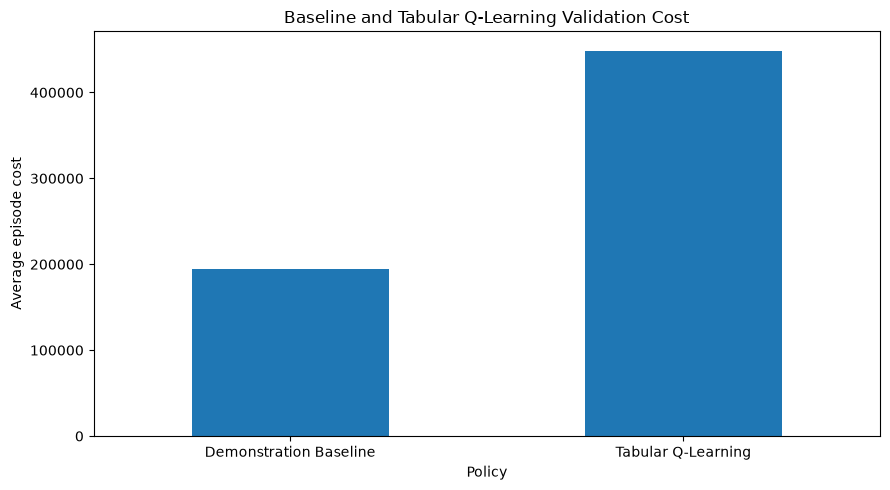

In [47]:
ax = q_learning_comparison.plot(
    x="policy",
    y="average_cost",
    kind="bar",
    figsize=(9, 5),
    legend=False,
    title=(
        "Baseline and Tabular Q-Learning "
        "Validation Cost"
    ),
)

ax.set_xlabel("Policy")
ax.set_ylabel("Average episode cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
import pickle

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

Q_LEARNING_MODEL_FILE = (
    MODELS_DIR
    / "q_learning_table.pkl"
)

q_learning_table_for_saving = {
    tuple(state): np.asarray(
        q_values,
        dtype=np.float64,
    )
    for state, q_values
    in q_learning_table.items()
}

with open(
    Q_LEARNING_MODEL_FILE,
    "wb",
) as model_file:
    pickle.dump(
        q_learning_table_for_saving,
        model_file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

print("Saved Q-Learning model:", Q_LEARNING_MODEL_FILE)
print(
    "Saved states:",
    len(q_learning_table_for_saving),
)

Saved Q-Learning model: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\models\q_learning_table.pkl
Saved states: 989


In [49]:
with open(
    Q_LEARNING_MODEL_FILE,
    "rb",
) as model_file:
    reloaded_q_learning_table = pickle.load(
        model_file
    )

assert isinstance(
    reloaded_q_learning_table,
    dict,
)

assert len(
    reloaded_q_learning_table
) == len(
    q_learning_table_for_saving
)

for state, expected_values in (
    q_learning_table_for_saving.items()
):
    assert state in reloaded_q_learning_table

    assert np.array_equal(
        expected_values,
        reloaded_q_learning_table[state],
    )

print("Q-Learning model reload verification: PASS")

Q-Learning model reload verification: PASS


In [50]:
def inspect_q_learning_episode(
    seed=2001,
    scenario_mode="mixed",
):
    inspection_env = IndustrialInventoryEnv(
        student_config=student_config,
        scenario_mode=scenario_mode,
        domain_randomization=True,
    )

    observation, _ = inspection_env.reset(seed=seed)
    action_records = []

    while True:
        state = tabular_state(observation)
        state_seen = state in q_learning_table
        quantities = q_learning_policy(observation)

        (
            next_observation,
            reward,
            terminated,
            truncated,
            info,
        ) = inspection_env.step(
            inspection_env.quantities_to_action_indices(
                quantities
            )
        )

        action_records.append(
            {
                "day": int(info["day"]),
                "state_seen": state_seen,
                "order_p1": int(quantities[0]),
                "order_p2": int(quantities[1]),
                "order_p3": int(quantities[2]),
                "stockout_cost": float(
                    info["costs"]["stockout"]
                ),
                "daily_cost": float(
                    info["costs"]["daily_total"]
                ),
            }
        )

        observation = next_observation

        if terminated or truncated:
            break

    return pd.DataFrame(action_records)


q_learning_action_check = inspect_q_learning_episode()

display(q_learning_action_check.head(10))

,day,state_seen,order_p1,order_p2,order_p3,stockout_cost,daily_cost
0,0,True,60,0,0,0.0,2510.0
1,1,True,0,0,0,0.0,1515.0
2,2,True,0,0,0,0.0,912.5
3,3,True,0,0,0,7200.0,7975.0
4,4,True,0,0,0,11400.0,11540.0
5,5,True,0,0,0,21800.0,21800.0
6,6,True,0,0,0,33300.0,33300.0
7,7,True,0,0,0,29100.0,29100.0
8,8,True,0,0,0,28100.0,28100.0
9,9,True,0,0,0,33000.0,33000.0


In [51]:
unseen_state_percentage = (
    100.0
    * (
        1.0
        - q_learning_action_check[
            "state_seen"
        ].mean()
    )
)

all_zero_mask = (
    q_learning_action_check[
        ["order_p1", "order_p2", "order_p3"]
    ].sum(axis=1)
    == 0
)

all_zero_action_percentage = (
    100.0 * all_zero_mask.mean()
)

print(
    "Unseen-state percentage:",
    f"{unseen_state_percentage:.2f}%",
)
print(
    "All-zero action percentage:",
    f"{all_zero_action_percentage:.2f}%",
)

Unseen-state percentage: 60.00%
All-zero action percentage: 38.00%


In [52]:
q_learning_scenario_summary = (
    q_learning_validation_results
    .groupby("scenario")
    .agg(
        episodes=("total_cost", "count"),
        average_cost=("total_cost", "mean"),
        cost_std=("total_cost", "std"),
        average_holding_cost=(
            "holding_cost",
            "mean",
        ),
        average_stockout_cost=(
            "stockout_cost",
            "mean",
        ),
        average_ordering_cost=(
            "ordering_cost",
            "mean",
        ),
        average_discarding_cost=(
            "discarding_cost",
            "mean",
        ),
        average_service_level=(
            "service_level",
            "mean",
        ),
    )
    .reset_index()
    .sort_values("average_cost")
)

display(q_learning_scenario_summary)

,scenario,episodes,average_cost,cost_std,average_holding_cost,average_stockout_cost,average_ordering_cost,average_discarding_cost,average_service_level
1,seasonal,5,434866.0,64461.198324,40514.0,382000.0,12352.0,0.0,0.782245
3,stationary,5,436150.0,130727.906534,70430.0,299940.0,12640.0,53140.0,0.827013
2,shock,5,436686.0,57352.667021,47542.0,370820.0,12584.0,5740.0,0.791517
4,trend,5,454915.0,15194.742615,39431.0,403180.0,12304.0,0.0,0.770762
0,mixed,5,480921.0,37211.764042,59851.0,367200.0,12840.0,41030.0,0.791542


### Q-Learning policy validation

I exported the frozen Q-Learning policy directly to `leaderboard/q_learning/policy.py` and checked that the exported action matched the notebook policy over a complete local episode. I then ran the supplied `policy_validation_tests.py` script on the same file.


In [53]:
from pathlib import Path
import shutil

assert Q_LEARNING_MODEL_FILE.exists(), (
    f"Trained Q-table not found: {Q_LEARNING_MODEL_FILE}"
)

# Simple output paths, without timestamps or versioned names.
Q_LEARNING_LEADERBOARD_DIR = PROJECT_DIR / "leaderboard" / "q_learning"
Q_LEARNING_LEADERBOARD_DIR.mkdir(parents=True, exist_ok=True)

Q_LEARNING_LEADERBOARD_POLICY = (
    Q_LEARNING_LEADERBOARD_DIR / "policy.py"
)
Q_LEARNING_LEADERBOARD_MODEL = (
    Q_LEARNING_LEADERBOARD_DIR / "q_learning_table.pkl"
)

q_learning_policy_source = 'from pathlib import Path\nimport pickle\nimport numpy as np\n\nTABULAR_ACTION_LEVELS = np.asarray([0, 20, 40, 60, 80, 100], dtype=np.int64)\nTABULAR_ACTIONS = np.asarray([\n    [product_1, product_2, product_3]\n    for product_1 in TABULAR_ACTION_LEVELS\n    for product_2 in TABULAR_ACTION_LEVELS\n    for product_3 in TABULAR_ACTION_LEVELS\n], dtype=np.int64)\n\n\ndef _find_model_file():\n    policy_dir = Path(__file__).resolve().parent\n    candidates = [\n        policy_dir / "q_learning_table.pkl",\n        policy_dir.parent / "models" / "q_learning_table.pkl",\n    ]\n    for candidate in candidates:\n        if candidate.exists():\n            return candidate\n    raise FileNotFoundError("q_learning_table.pkl was not found")\n\n\nwith _find_model_file().open("rb") as model_file:\n    Q_TABLE = pickle.load(model_file)\n\n\ndef _recent_mean_demand(observation):\n    history = np.asarray(observation["demand_history"], dtype=np.float64)\n    observed_rows = history[np.any(history > 0, axis=1)]\n    if len(observed_rows) == 0:\n        return np.asarray([33.0, 25.0, 31.5], dtype=np.float64)\n    return observed_rows.mean(axis=0)\n\n\ndef _discretize_ratio(value):\n    if value < 0.75:\n        return 0\n    if value < 1.25:\n        return 1\n    if value < 1.75:\n        return 2\n    if value < 2.50:\n        return 3\n    return 4\n\n\ndef _tabular_state(observation):\n    inventory = np.asarray(observation["inventory"], dtype=np.float64)\n    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float64)\n    demand_mean = _recent_mean_demand(observation)\n    inventory_position = inventory + pipeline.sum(axis=1)\n    lead_times = np.asarray([3.0, 2.0, 1.0], dtype=np.float64)\n    expected_demand = np.maximum(demand_mean * lead_times, 1.0)\n    coverage_bins = tuple(\n        _discretize_ratio(value)\n        for value in inventory_position / expected_demand\n    )\n\n    capacity = float(\n        np.asarray(observation["capacity_utilisation"]).reshape(-1)[0]\n    )\n    if capacity < 0.40:\n        capacity_bin = 0\n    elif capacity < 0.70:\n        capacity_bin = 1\n    elif capacity < 0.90:\n        capacity_bin = 2\n    else:\n        capacity_bin = 3\n\n    day = int(np.asarray(observation["day"]).reshape(-1)[0])\n    day_bin = min(day // 10, 4)\n    return coverage_bins + (capacity_bin, day_bin)\n\n\ndef _fallback_policy(observation):\n    inventory = np.asarray(observation["inventory"], dtype=np.float64)\n    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float64)\n    inventory_position = inventory + pipeline.sum(axis=1)\n    targets = np.asarray([110.0, 100.0, 120.0], dtype=np.float64)\n    required = np.maximum(targets - inventory_position, 0.0)\n    quantities = np.ceil(required / 10.0) * 10.0\n    return np.clip(quantities, 0.0, 100.0).astype(int).tolist()\n\n\ndef run_policy(observation):\n    """Return deterministic learned order quantities for three products."""\n    state = _tabular_state(observation)\n    if state not in Q_TABLE:\n        return _fallback_policy(observation)\n    q_values = np.asarray(Q_TABLE[state], dtype=np.float64)\n    best_action_index = int(np.argmax(q_values))\n    return TABULAR_ACTIONS[best_action_index].astype(int).tolist()\n'

# Write the standalone policy directly to the leaderboard folder.
Q_LEARNING_LEADERBOARD_POLICY.write_text(
    q_learning_policy_source,
    encoding="utf-8",
)
shutil.copy2(
    Q_LEARNING_MODEL_FILE,
    Q_LEARNING_LEADERBOARD_MODEL,
)

print("Trained model:", Q_LEARNING_MODEL_FILE.resolve())
print("Leaderboard policy:", Q_LEARNING_LEADERBOARD_POLICY.resolve())
print("Leaderboard model:", Q_LEARNING_LEADERBOARD_MODEL.resolve())
print("Model folder file exists:", Q_LEARNING_MODEL_FILE.exists())
print("Leaderboard policy exists:", Q_LEARNING_LEADERBOARD_POLICY.exists())
print("Leaderboard model exists:", Q_LEARNING_LEADERBOARD_MODEL.exists())


Trained model: C:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\models\q_learning_table.pkl
Leaderboard policy: C:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\q_learning\policy.py
Leaderboard model: C:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\q_learning\q_learning_table.pkl
Model folder file exists: True
Leaderboard policy exists: True
Leaderboard model exists: True


In [54]:
import importlib.util
import sys
import uuid


def load_policy_module(policy_path):
    module_name = f"q_learning_submission_{uuid.uuid4().hex}"
    spec = importlib.util.spec_from_file_location(module_name, policy_path)
    assert spec is not None and spec.loader is not None
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


leaderboard_module = load_policy_module(Q_LEARNING_LEADERBOARD_POLICY)

test_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="mixed",
    domain_randomization=True,
)
observation, _ = test_env.reset(seed=1001)

for _ in range(50):
    expected_action = q_learning_policy(observation)
    leaderboard_action = leaderboard_module.run_policy(observation)

    assert leaderboard_action == expected_action

    action_indices = test_env.quantities_to_action_indices(leaderboard_action)
    observation, _, terminated, truncated, _ = test_env.step(action_indices)
    if terminated or truncated:
        break

print("Leaderboard policy matches trained notebook policy: PASS")


Leaderboard policy matches trained notebook policy: PASS


In [55]:
import subprocess
import sys

for policy_path in [Q_LEARNING_LEADERBOARD_POLICY]:
    result = subprocess.run(
        [
            sys.executable,
            str(PROJECT_DIR / "policy_validation_tests.py"),
            str(policy_path),
        ],
        cwd=PROJECT_DIR,
        capture_output=True,
        text=True,
    )

    print("Validating:", policy_path.resolve())
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    assert result.returncode == 0, f"Validation failed: {policy_path}"

print("Q-Learning leaderboard policy validation: PASS")


Validating: C:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\q_learning\policy.py
Policy file: C:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\q_learning\policy.py
Import/model-loading time: 0.0066s
Average inference time: 0.000047s per call

VALIDATION PASSED
The policy satisfies the local interface checks. Passing this script does not guarantee leaderboard eligibility, security compliance or performance.

Q-Learning leaderboard policy validation: PASS


## 12. Technique 2: Tabular SARSA

For the final notebook I restored the original Tabular SARSA experiment because the later optimized variant did not pass my leaderboard checks. This version uses the original 13 joint actions, 3,000 episodes, alpha 0.10, gamma 0.99 and the original epsilon schedule. I have not presented this restored version as an optimization.


In [56]:
SARSA_RANDOM_SEED = 1543
SARSA_TEST_EPISODES = 20
SARSA_EPISODES = 3000
SARSA_ALPHA = 0.10
SARSA_GAMMA = 0.99
SARSA_EPSILON_START = 1.00
SARSA_EPSILON_END = 0.05
SARSA_EPSILON_DECAY = 0.9985

SARSA_ACTIONS = np.asarray(
    [
        [0, 0, 0],
        [20, 20, 20],
        [30, 20, 30],
        [30, 30, 30],
        [40, 30, 40],
        [40, 40, 40],
        [50, 40, 50],
        [50, 50, 50],
        [60, 50, 60],
        [60, 60, 60],
        [70, 60, 70],
        [80, 70, 80],
        [100, 100, 100],
    ],
    dtype=np.int64,
)

if SARSA_ACTIONS.shape != (13, 3):
    raise RuntimeError(f"Original SARSA action array has shape {SARSA_ACTIONS.shape}.")
print("Original Tabular SARSA configuration restored.")


Original Tabular SARSA configuration restored.


In [57]:
def choose_sarsa_action(sarsa_table, state, epsilon, rng):
    """Choose an epsilon-greedy action from the SARSA table."""
    if rng.random() < epsilon:
        return int(rng.integers(len(SARSA_ACTIONS)))

    q_values = np.asarray(sarsa_table[state], dtype=np.float64)
    best_actions = np.flatnonzero(np.isclose(q_values, np.max(q_values)))
    return int(rng.choice(best_actions))


def train_sarsa(
    student_config,
    episodes,
    alpha=SARSA_ALPHA,
    gamma=SARSA_GAMMA,
    epsilon_start=SARSA_EPSILON_START,
    epsilon_end=SARSA_EPSILON_END,
    epsilon_decay=SARSA_EPSILON_DECAY,
    random_seed=SARSA_RANDOM_SEED,
    progress_interval=100,
):
    """Train a separate tabular SARSA policy."""
    rng = np.random.default_rng(random_seed)
    sarsa_table = make_q_table(len(SARSA_ACTIONS))
    records = []
    epsilon = float(epsilon_start)
    training_start = time.perf_counter()

    for episode in range(1, episodes + 1):
        training_env = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True,
        )
        environment_seed = int(rng.integers(1, 1_000_000_000))
        observation, _ = training_env.reset(seed=environment_seed)
        state = tabular_state(observation)
        action_index = choose_sarsa_action(
            sarsa_table, state, epsilon, rng
        )

        totals = {
            "episode_reward": 0.0,
            "episode_cost": 0.0,
            "holding_cost": 0.0,
            "stockout_cost": 0.0,
            "ordering_cost": 0.0,
            "discarding_cost": 0.0,
        }
        steps = 0

        while True:
            quantities = SARSA_ACTIONS[action_index]
            internal_action = training_env.quantities_to_action_indices(quantities)
            next_observation, reward, terminated, truncated, step_info = (
                training_env.step(internal_action)
            )
            done = terminated or truncated
            next_state = tabular_state(next_observation)

            if done:
                next_action_index = None
                next_q_value = 0.0
            else:
                next_action_index = choose_sarsa_action(
                    sarsa_table, next_state, epsilon, rng
                )
                next_q_value = float(
                    sarsa_table[next_state][next_action_index]
                )

            old_value = sarsa_table[state][action_index]
            target = float(reward) + gamma * next_q_value
            sarsa_table[state][action_index] = (
                old_value + alpha * (target - old_value)
            )

            costs = step_info["costs"]
            totals["episode_reward"] += float(reward)
            totals["episode_cost"] += float(costs["daily_total"])
            totals["holding_cost"] += float(costs["holding"])
            totals["stockout_cost"] += float(costs["stockout"])
            totals["ordering_cost"] += float(costs["ordering"])
            totals["discarding_cost"] += float(costs["discarding"])
            steps += 1

            if done:
                break

            observation = next_observation
            state = next_state
            action_index = next_action_index

        records.append({
            "episode": episode,
            "environment_seed": environment_seed,
            "epsilon": epsilon,
            **totals,
            "steps": steps,
            "states_seen": len(sarsa_table),
        })
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        if episode == 1 or episode % progress_interval == 0 or episode == episodes:
            recent_costs = [r["episode_cost"] for r in records[-100:]]
            print(
                f"Episode {episode:5d}/{episodes}, "
                f"epsilon={epsilon:.4f}, "
                f"recent_mean_cost={np.mean(recent_costs):.2f}, "
                f"states={len(sarsa_table)}"
            )

    training_seconds = time.perf_counter() - training_start
    return sarsa_table, pd.DataFrame(records), training_seconds

print("SARSA training function created successfully.")

SARSA training function created successfully.


In [58]:
# Short smoke test before the full run.
sarsa_table_test, sarsa_test_results, sarsa_test_seconds = train_sarsa(
    student_config=student_config,
    episodes=SARSA_TEST_EPISODES,
    progress_interval=5,
)

assert len(sarsa_test_results) == SARSA_TEST_EPISODES
assert sarsa_test_results["steps"].eq(50).all()
assert len(sarsa_table_test) > 0
assert np.isfinite(sarsa_test_results["episode_cost"]).all()

print("SARSA smoke test: PASS")

Episode     1/20, epsilon=0.9985, recent_mean_cost=656032.50, states=24
Episode     5/20, epsilon=0.9925, recent_mean_cost=727396.00, states=47
Episode    10/20, epsilon=0.9851, recent_mean_cost=694179.50, states=64
Episode    15/20, epsilon=0.9777, recent_mean_cost=669223.17, states=75
Episode    20/20, epsilon=0.9704, recent_mean_cost=682866.88, states=83
SARSA smoke test: PASS


In [59]:
# Full SARSA training run.
sarsa_table, sarsa_training_results, sarsa_training_seconds = train_sarsa(
    student_config=student_config,
    episodes=SARSA_EPISODES,
    progress_interval=100,
)

assert len(sarsa_training_results) == SARSA_EPISODES
assert sarsa_training_results["steps"].eq(50).all()

SARSA_TRAINING_FILE = RESULTS_DIR / "sarsa_training_results.csv"
sarsa_training_results.to_csv(SARSA_TRAINING_FILE, index=False)

print("SARSA training completed.")
print("Visited states:", len(sarsa_table))
print("Training seconds:", sarsa_training_seconds)
print(
    "Last 100 average cost:",
    sarsa_training_results["episode_cost"].tail(100).mean(),
)
print("Saved:", SARSA_TRAINING_FILE)

Episode     1/3000, epsilon=0.9985, recent_mean_cost=656032.50, states=24
Episode   100/3000, epsilon=0.8606, recent_mean_cost=685758.32, states=169
Episode   200/3000, epsilon=0.7407, recent_mean_cost=612657.55, states=255
Episode   300/3000, epsilon=0.6374, recent_mean_cost=491751.22, states=344
Episode   400/3000, epsilon=0.5486, recent_mean_cost=407348.12, states=414
Episode   500/3000, epsilon=0.4721, recent_mean_cost=353779.65, states=488
Episode   600/3000, epsilon=0.4063, recent_mean_cost=316041.38, states=546
Episode   700/3000, epsilon=0.3497, recent_mean_cost=295723.12, states=590
Episode   800/3000, epsilon=0.3009, recent_mean_cost=282591.10, states=625
Episode   900/3000, epsilon=0.2590, recent_mean_cost=266364.83, states=672
Episode  1000/3000, epsilon=0.2229, recent_mean_cost=247639.85, states=697
Episode  1100/3000, epsilon=0.1918, recent_mean_cost=242655.45, states=733
Episode  1200/3000, epsilon=0.1651, recent_mean_cost=243957.27, states=758
Episode  1300/3000, epsilo

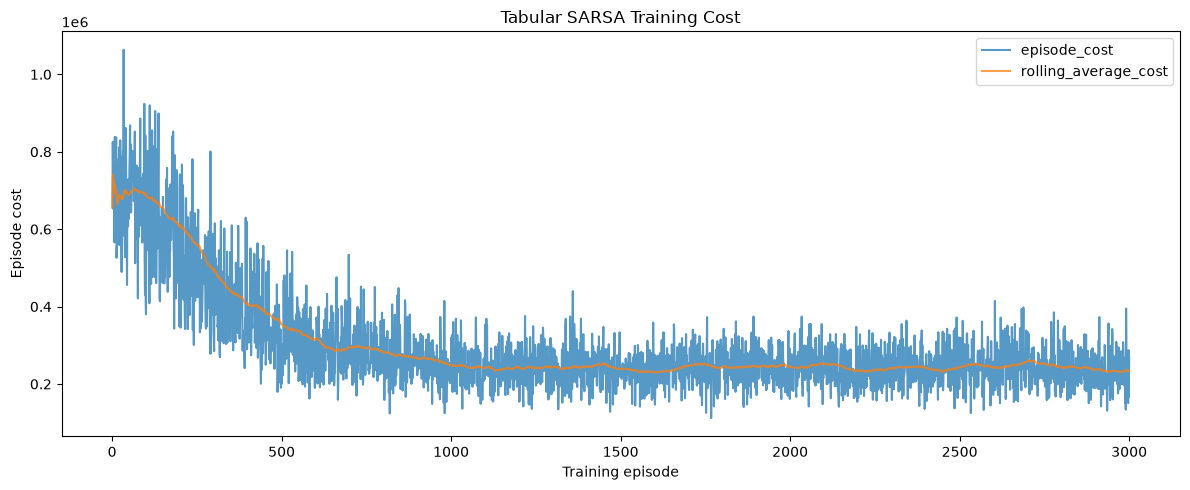

In [60]:
sarsa_plot_data = sarsa_training_results.copy()
sarsa_plot_data["rolling_average_cost"] = (
    sarsa_plot_data["episode_cost"].rolling(100, min_periods=1).mean()
)

ax = sarsa_plot_data.plot(
    x="episode",
    y=["episode_cost", "rolling_average_cost"],
    figsize=(12, 5),
    alpha=0.75,
    title="Tabular SARSA Training Cost",
)
ax.set_xlabel("Training episode")
ax.set_ylabel("Episode cost")
plt.tight_layout()
plt.show()

In [61]:
def sarsa_policy(observation):
    """Return deterministic quantities from the trained SARSA table."""
    state = tabular_state(observation)
    if state not in sarsa_table:
        return demonstration_policy(observation)
    q_values = np.asarray(sarsa_table[state], dtype=np.float64)
    action_index = int(np.argmax(q_values))
    return SARSA_ACTIONS[action_index].astype(int).tolist()

sarsa_test_env = IndustrialInventoryEnv(
    student_config=student_config,
    scenario_mode="random",
    domain_randomization=True,
)
sarsa_test_observation, _ = sarsa_test_env.reset(seed=2002)
first_action = sarsa_policy(sarsa_test_observation)
second_action = sarsa_policy(sarsa_test_observation)

assert first_action == second_action
validate_order_quantities(first_action)
print("First SARSA action:", first_action)
print("SARSA deterministic inference: PASS")

First SARSA action: [50, 40, 50]
SARSA deterministic inference: PASS


In [62]:
sarsa_validation_results = evaluate_policy(
    policy=sarsa_policy,
    student_config=student_config,
    seeds=VALIDATION_SEEDS,
    scenario_modes=VALIDATION_SCENARIOS,
    policy_name="Tabular SARSA",
)

assert len(sarsa_validation_results) == 25
assert sarsa_validation_results["days"].eq(50).all()
assert np.allclose(
    sarsa_validation_results["total_cost"],
    sarsa_validation_results[
        ["holding_cost", "stockout_cost", "ordering_cost", "discarding_cost"]
    ].sum(axis=1),
)

print("SARSA validation episodes:", len(sarsa_validation_results))
print("SARSA validation consistency checks: PASS")

SARSA validation episodes: 25
SARSA validation consistency checks: PASS


In [63]:
sarsa_summary = pd.DataFrame([{
    "policy": "Tabular SARSA",
    "episodes": len(sarsa_validation_results),
    "average_cost": sarsa_validation_results["total_cost"].mean(),
    "standard_deviation": sarsa_validation_results["total_cost"].std(),
    "median_cost": sarsa_validation_results["total_cost"].median(),
    "minimum_cost": sarsa_validation_results["total_cost"].min(),
    "maximum_cost": sarsa_validation_results["total_cost"].max(),
    "average_holding_cost": sarsa_validation_results["holding_cost"].mean(),
    "average_stockout_cost": sarsa_validation_results["stockout_cost"].mean(),
    "average_ordering_cost": sarsa_validation_results["ordering_cost"].mean(),
    "average_discarding_cost": sarsa_validation_results["discarding_cost"].mean(),
    "average_service_level": sarsa_validation_results["service_level"].mean(),
    "average_stockout_days": sarsa_validation_results["stockout_days"].mean(),
    "mean_inference_seconds": sarsa_validation_results["mean_inference_seconds"].mean(),
}])

display(sarsa_summary)

SARSA_VALIDATION_FILE = RESULTS_DIR / "sarsa_validation_episode_results.csv"
SARSA_SUMMARY_FILE = RESULTS_DIR / "sarsa_validation_summary.csv"
sarsa_validation_results.to_csv(SARSA_VALIDATION_FILE, index=False)
sarsa_summary.to_csv(SARSA_SUMMARY_FILE, index=False)

print("SARSA results saved: PASS")

,policy,episodes,average_cost,standard_deviation,median_cost,minimum_cost,maximum_cost,average_holding_cost,average_stockout_cost,average_ordering_cost,average_discarding_cost,average_service_level,average_stockout_days,mean_inference_seconds
0,Tabular SARSA,25,259092.2,39997.37698,248960.0,204640.0,341572.5,98200.2,141756.0,13424.0,5712.0,0.912848,21.44,0.000071


SARSA results saved: PASS


In [64]:
# Save a portable SARSA table.
import pickle

SARSA_MODEL_FILE = MODELS_DIR / "sarsa_table.pkl"
portable_sarsa_table = {
    tuple(state): np.asarray(values, dtype=np.float64)
    for state, values in sarsa_table.items()
}

with SARSA_MODEL_FILE.open("wb") as model_file:
    pickle.dump(portable_sarsa_table, model_file, protocol=pickle.HIGHEST_PROTOCOL)

with SARSA_MODEL_FILE.open("rb") as model_file:
    reloaded_sarsa_table = pickle.load(model_file)

assert len(reloaded_sarsa_table) == len(portable_sarsa_table)
print("SARSA model save and reload: PASS")

SARSA model save and reload: PASS


In [65]:
from pathlib import Path
import shutil

SARSA_LEADERBOARD_DIR = PROJECT_DIR / "leaderboard" / "sarsa"
SARSA_LEADERBOARD_DIR.mkdir(parents=True, exist_ok=True)
SARSA_POLICY_FILE = SARSA_LEADERBOARD_DIR / "policy.py"
SARSA_LEADERBOARD_MODEL = SARSA_LEADERBOARD_DIR / "sarsa_table.pkl"

sarsa_policy_source = r'''from pathlib import Path
import pickle
import numpy as np

TABULAR_ACTIONS = np.asarray([
    [0, 0, 0], [20, 20, 20], [30, 20, 30], [30, 30, 30],
    [40, 30, 40], [40, 40, 40], [50, 40, 50], [50, 50, 50],
    [60, 50, 60], [60, 60, 60], [70, 60, 70], [80, 70, 80],
    [100, 100, 100],
], dtype=np.int64)

MODEL_FILE = Path(__file__).resolve().parent / "sarsa_table.pkl"
with MODEL_FILE.open("rb") as model_file:
    SARSA_TABLE = pickle.load(model_file)

def _recent_mean_demand(observation):
    history = np.asarray(observation["demand_history"], dtype=np.float64)
    observed_rows = history[np.any(history > 0, axis=1)]
    if len(observed_rows) == 0:
        return np.asarray([33.0, 25.0, 31.5], dtype=np.float64)
    return observed_rows.mean(axis=0)

def _discretize_ratio(value):
    if value < 0.75: return 0
    if value < 1.25: return 1
    if value < 1.75: return 2
    if value < 2.50: return 3
    return 4

def _tabular_state(observation):
    inventory = np.asarray(observation["inventory"], dtype=np.float64)
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float64)
    demand_mean = _recent_mean_demand(observation)
    inventory_position = inventory + pipeline.sum(axis=1)
    reference_lead_times = np.asarray([3.0, 2.0, 1.0], dtype=np.float64)
    expected = np.maximum(demand_mean * reference_lead_times, 1.0)
    coverage_bins = tuple(
        _discretize_ratio(value) for value in inventory_position / expected
    )
    capacity = float(np.asarray(observation["capacity_utilisation"]).reshape(-1)[0])
    if capacity < 0.40: capacity_bin = 0
    elif capacity < 0.70: capacity_bin = 1
    elif capacity < 0.90: capacity_bin = 2
    else: capacity_bin = 3
    day = int(np.asarray(observation["day"]).reshape(-1)[0])
    return coverage_bins + (capacity_bin, min(day // 10, 4))

def _fallback(observation):
    inventory = np.asarray(observation["inventory"], dtype=np.float64)
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float64)
    position = inventory + pipeline.sum(axis=1)
    required = np.maximum(np.asarray([110.0, 100.0, 120.0]) - position, 0.0)
    quantities = np.clip(np.ceil(required / 10.0) * 10.0, 0.0, 100.0)
    return quantities.astype(int).tolist()

def run_policy(observation):
    state = _tabular_state(observation)
    if state not in SARSA_TABLE:
        return _fallback(observation)
    action_index = int(np.argmax(np.asarray(SARSA_TABLE[state], dtype=np.float64)))
    return TABULAR_ACTIONS[action_index].astype(int).tolist()
'''

SARSA_POLICY_FILE.write_text(sarsa_policy_source, encoding="utf-8")
shutil.copy2(SARSA_MODEL_FILE, SARSA_LEADERBOARD_MODEL)

print("SARSA policy:", SARSA_POLICY_FILE)
print("SARSA model:", SARSA_LEADERBOARD_MODEL)
assert SARSA_POLICY_FILE.exists() and SARSA_LEADERBOARD_MODEL.exists()
print("SARSA leaderboard files created: PASS")

SARSA policy: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\sarsa\policy.py
SARSA model: c:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\sarsa\sarsa_table.pkl
SARSA leaderboard files created: PASS


In [66]:
# Validate the exact SARSA leaderboard policy.
import subprocess
import sys

sarsa_validation_process = subprocess.run(
    [
        sys.executable,
        str(PROJECT_DIR / "policy_validation_tests.py"),
        str(SARSA_POLICY_FILE),
    ],
    cwd=PROJECT_DIR,
    capture_output=True,
    text=True,
)
print(sarsa_validation_process.stdout)
if sarsa_validation_process.stderr:
    print(sarsa_validation_process.stderr)
assert sarsa_validation_process.returncode == 0
print("Official SARSA policy validation: PASS")

Policy file: C:\Users\nxf38366\Desktop\personal_doc\M.Tech Assignment\M.Tech_DM_RL_MLOPS\ORL\RL_Inventory_Project\RL_Inventry_Project\leaderboard\sarsa\policy.py
Import/model-loading time: 0.0139s
Average inference time: 0.000052s per call

VALIDATION PASSED
The policy satisfies the local interface checks. Passing this script does not guarantee leaderboard eligibility, security compliance or performance.

Official SARSA policy validation: PASS


## 13. Shared Neural-Network Utilities

The following utilities are used by DQN, Double DQN, and PPO. The neural policies use a normalized 38-value observation and three factorized 11-action heads. Each head selects a legal order index from 0 to 10, which is converted to an actual quantity from 0 to 100. Training uses random scenarios with domain randomization. Validation uses the same fixed held-out seeds and scenarios used for the tabular techniques.


In [67]:
import copy
import math
import random
from collections import deque, namedtuple

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.distributions import Categorical

NEURAL_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEURAL_SEED = 2543
random.seed(NEURAL_SEED)
np.random.seed(NEURAL_SEED)
torch.manual_seed(NEURAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(NEURAL_SEED)

STATE_DIM = 38
NUM_PRODUCTS = 3
ACTIONS_PER_PRODUCT = 11


def flatten_observation(observation):
    """Return the normalized 38-value network input."""
    inventory = np.asarray(observation["inventory"], dtype=np.float32) / 1000.0
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float32).reshape(-1) / 400.0
    history = np.asarray(observation["demand_history"], dtype=np.float32).reshape(-1) / 100.0
    day = np.asarray(observation["day"], dtype=np.float32).reshape(-1) / 50.0
    capacity = np.asarray(observation["capacity_utilisation"], dtype=np.float32).reshape(-1)
    state = np.concatenate([inventory, pipeline, history, day, capacity]).astype(np.float32)
    assert state.shape == (STATE_DIM,)
    return state


def action_indices_to_quantities(action_indices):
    indices = np.asarray(action_indices, dtype=np.int64)
    assert indices.shape == (3,)
    return (np.clip(indices, 0, 10) * 10).astype(int).tolist()

print("Neural device:", NEURAL_DEVICE)
print("State dimension:", STATE_DIM)
print("Neural preprocessing: PASS")


Neural device: cpu
State dimension: 38
Neural preprocessing: PASS


## 14. Deep Q-Network (DQN)

DQN uses online and target networks, replay memory, Huber loss, gradient clipping, epsilon-greedy exploration, and a factorized three-head action representation. The target uses the maximum value from the target network.


In [ ]:
class FactoredQNetwork(nn.Module):
    def __init__(self, state_dim=STATE_DIM, hidden_dim=256):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.heads = nn.ModuleList([
            nn.Linear(hidden_dim, ACTIONS_PER_PRODUCT) for _ in range(NUM_PRODUCTS)
        ])

    def forward(self, states):
        features = self.backbone(states)
        return torch.stack([head(features) for head in self.heads], dim=1)


Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


def train_factored_dqn(
    student_config,
    episodes,
    double_dqn=False,
    seed=NEURAL_SEED,
    learning_rate=3e-4,
    gamma=0.99,
    batch_size=128,
    replay_capacity=100_000,
    warmup_steps=2_000,
    target_update_interval=1_000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_steps=45_000,
    hidden_dim=256,
    progress_interval=100,
):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    online = FactoredQNetwork(hidden_dim=hidden_dim).to(NEURAL_DEVICE)
    target = FactoredQNetwork(hidden_dim=hidden_dim).to(NEURAL_DEVICE)
    target.load_state_dict(online.state_dict())
    target.eval()
    optimizer = torch.optim.AdamW(online.parameters(), lr=learning_rate, weight_decay=1e-5)
    replay = deque(maxlen=replay_capacity)
    records = []
    global_step = 0

    for episode in range(1, episodes + 1):
        env = IndustrialInventoryEnv(student_config, scenario_mode="random", domain_randomization=True)
        observation, _ = env.reset(seed=int(rng.integers(1, 1_000_000_000)))
        state = flatten_observation(observation)
        episode_cost = 0.0
        episode_reward = 0.0
        losses = []

        while True:
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(-global_step / epsilon_decay_steps)
            if rng.random() < epsilon:
                action = rng.integers(0, ACTIONS_PER_PRODUCT, size=NUM_PRODUCTS, dtype=np.int64)
            else:
                with torch.no_grad():
                    tensor_state = torch.as_tensor(state, device=NEURAL_DEVICE).unsqueeze(0)
                    action = online(tensor_state).argmax(dim=2).squeeze(0).cpu().numpy()

            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = flatten_observation(next_observation)
            replay.append(Transition(state, action, float(reward), next_state, done))
            state = next_state
            episode_reward += float(reward)
            episode_cost += float(info["costs"]["daily_total"])
            global_step += 1

            if len(replay) >= max(batch_size, warmup_steps):
                indices = rng.choice(len(replay), size=batch_size, replace=False)
                batch = [replay[int(i)] for i in indices]
                states = torch.as_tensor(np.stack([t.state for t in batch]), device=NEURAL_DEVICE)
                actions = torch.as_tensor(np.stack([t.action for t in batch]), dtype=torch.long, device=NEURAL_DEVICE)
                rewards = torch.as_tensor([t.reward for t in batch], dtype=torch.float32, device=NEURAL_DEVICE)
                next_states = torch.as_tensor(np.stack([t.next_state for t in batch]), device=NEURAL_DEVICE)
                dones = torch.as_tensor([t.done for t in batch], dtype=torch.float32, device=NEURAL_DEVICE)

                current_all = online(states)
                current = current_all.gather(2, actions.unsqueeze(-1)).squeeze(-1).sum(dim=1)
                with torch.no_grad():
                    if double_dqn:
                        next_actions = online(next_states).argmax(dim=2, keepdim=True)
                        next_values = target(next_states).gather(2, next_actions).squeeze(-1).sum(dim=1)
                    else:
                        next_values = target(next_states).max(dim=2).values.sum(dim=1)
                    targets = rewards + gamma * (1.0 - dones) * next_values

                loss = nn.functional.smooth_l1_loss(current, targets)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 10.0)
                optimizer.step()
                losses.append(float(loss.item()))

            if global_step % target_update_interval == 0:
                target.load_state_dict(online.state_dict())
            if done:
                break

        records.append({
            "episode": episode, "episode_cost": episode_cost, "episode_reward": episode_reward,
            "epsilon": epsilon, "mean_loss": np.mean(losses) if losses else np.nan,
            "global_step": global_step,
        })
        if episode == 1 or episode % progress_interval == 0 or episode == episodes:
            recent = [row["episode_cost"] for row in records[-100:]]
            label = "Double DQN" if double_dqn else "DQN"
            print(f"{label} episode {episode}/{episodes}, recent mean cost={np.mean(recent):.2f}, epsilon={epsilon:.3f}")

    return online.cpu(), pd.DataFrame(records)

DQN_EPISODES = 1500
DQN_MODEL_FILE = MODELS_DIR / "dqn_model.pt"
dqn_model, dqn_training_results = train_factored_dqn(
    student_config, episodes=DQN_EPISODES, double_dqn=False, seed=NEURAL_SEED
)
torch.save({"state_dict": dqn_model.state_dict(), "hidden_dim": 256, "state_dim": STATE_DIM}, DQN_MODEL_FILE)
dqn_training_results.to_csv(RESULTS_DIR / "dqn_training_results.csv", index=False)
print("DQN training and save: PASS")


DQN episode 1/1500, recent mean cost=816690.00, epsilon=0.999
DQN episode 100/1500, recent mean cost=890634.55, epsilon=0.900
DQN episode 200/1500, recent mean cost=712776.30, epsilon=0.811
DQN episode 300/1500, recent mean cost=555181.68, epsilon=0.731
DQN episode 400/1500, recent mean cost=477132.20, epsilon=0.659


In [ ]:
def make_neural_q_policy(model):
    model.eval()
    def policy(observation):
        state = torch.as_tensor(flatten_observation(observation), dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            action = model(state).argmax(dim=2).squeeze(0).cpu().numpy()
        return action_indices_to_quantities(action)
    return policy

dqn_policy = make_neural_q_policy(dqn_model)
dqn_validation_results = evaluate_policy(
    dqn_policy, student_config, VALIDATION_SEEDS, VALIDATION_SCENARIOS, "DQN"
)
dqn_validation_results.to_csv(RESULTS_DIR / "dqn_validation_results.csv", index=False)
print("DQN average validation cost:", dqn_validation_results["total_cost"].mean())
print("DQN validation: PASS")


## 15. Double DQN

Double DQN uses the online network to select next actions and the target network to evaluate those actions. This separates action selection from target evaluation and reduces the overestimation mechanism present in standard DQN.


In [ ]:
DOUBLE_DQN_EPISODES = 1500
DOUBLE_DQN_MODEL_FILE = MODELS_DIR / "double_dqn_model.pt"
double_dqn_model, double_dqn_training_results = train_factored_dqn(
    student_config, episodes=DOUBLE_DQN_EPISODES, double_dqn=True, seed=NEURAL_SEED + 1
)
torch.save({"state_dict": double_dqn_model.state_dict(), "hidden_dim": 256, "state_dim": STATE_DIM}, DOUBLE_DQN_MODEL_FILE)
double_dqn_training_results.to_csv(RESULTS_DIR / "double_dqn_training_results.csv", index=False)
double_dqn_policy = make_neural_q_policy(double_dqn_model)
double_dqn_validation_results = evaluate_policy(
    double_dqn_policy, student_config, VALIDATION_SEEDS, VALIDATION_SCENARIOS, "Double DQN"
)
double_dqn_validation_results.to_csv(RESULTS_DIR / "double_dqn_validation_results.csv", index=False)
print("Double DQN average validation cost:", double_dqn_validation_results["total_cost"].mean())
print("Double DQN training and validation: PASS")


## 16. Proximal Policy Optimization (PPO)

PPO uses a shared actor-critic network with three categorical action heads, generalized advantage estimation, clipped policy updates, value loss, entropy regularization, mini-batches, and gradient clipping. Validation uses deterministic argmax actions.


In [ ]:
class FactoredActorCritic(nn.Module):
    def __init__(self, state_dim=STATE_DIM, hidden_dim=256):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor_heads = nn.ModuleList([nn.Linear(hidden_dim, ACTIONS_PER_PRODUCT) for _ in range(NUM_PRODUCTS)])
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, states):
        features = self.backbone(states)
        logits = torch.stack([head(features) for head in self.actor_heads], dim=1)
        values = self.critic(features).squeeze(-1)
        return logits, values


def train_ppo(
    student_config, episodes=2500, seed=NEURAL_SEED + 2, learning_rate=3e-4,
    gamma=0.99, gae_lambda=0.95, clip_ratio=0.20, update_epochs=8,
    mini_batch_size=256, entropy_coef=0.01, value_coef=0.5, hidden_dim=256,
    progress_interval=100,
):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    model = FactoredActorCritic(hidden_dim=hidden_dim).to(NEURAL_DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    records = []

    for episode in range(1, episodes + 1):
        env = IndustrialInventoryEnv(student_config, scenario_mode="random", domain_randomization=True)
        observation, _ = env.reset(seed=int(rng.integers(1, 1_000_000_000)))
        states=[]; actions=[]; rewards=[]; dones=[]; old_log_probs=[]; values=[]
        episode_cost=0.0

        while True:
            state = flatten_observation(observation)
            state_tensor = torch.as_tensor(state, device=NEURAL_DEVICE).unsqueeze(0)
            with torch.no_grad():
                logits, value = model(state_tensor)
                distributions = [Categorical(logits=logits[:, p, :]) for p in range(NUM_PRODUCTS)]
                sampled = torch.stack([dist.sample() for dist in distributions], dim=1)
                log_prob = torch.stack([dist.log_prob(sampled[:, p]) for p, dist in enumerate(distributions)], dim=1).sum(dim=1)
            action = sampled.squeeze(0).cpu().numpy()
            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            states.append(state); actions.append(action); rewards.append(float(reward)); dones.append(done)
            old_log_probs.append(float(log_prob.item())); values.append(float(value.item()))
            episode_cost += float(info["costs"]["daily_total"])
            observation = next_observation
            if done: break

        advantages = np.zeros(len(rewards), dtype=np.float32)
        last_gae = 0.0
        for t in reversed(range(len(rewards))):
            next_value = 0.0 if t == len(rewards)-1 else values[t+1]
            nonterminal = 0.0 if dones[t] else 1.0
            delta = rewards[t] + gamma * next_value * nonterminal - values[t]
            last_gae = delta + gamma * gae_lambda * nonterminal * last_gae
            advantages[t] = last_gae
        returns = advantages + np.asarray(values, dtype=np.float32)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        state_t = torch.as_tensor(np.stack(states), device=NEURAL_DEVICE)
        action_t = torch.as_tensor(np.stack(actions), dtype=torch.long, device=NEURAL_DEVICE)
        old_log_t = torch.as_tensor(old_log_probs, dtype=torch.float32, device=NEURAL_DEVICE)
        advantage_t = torch.as_tensor(advantages, device=NEURAL_DEVICE)
        return_t = torch.as_tensor(returns, device=NEURAL_DEVICE)
        n = len(states); epoch_losses=[]
        for _ in range(update_epochs):
            for start in range(0, n, mini_batch_size):
                idx = torch.as_tensor(rng.permutation(n)[start:start+mini_batch_size], device=NEURAL_DEVICE)
                logits, predicted_values = model(state_t[idx])
                dists = [Categorical(logits=logits[:, p, :]) for p in range(NUM_PRODUCTS)]
                new_log = torch.stack([dist.log_prob(action_t[idx, p]) for p, dist in enumerate(dists)], dim=1).sum(dim=1)
                entropy = torch.stack([dist.entropy() for dist in dists], dim=1).sum(dim=1).mean()
                ratio = torch.exp(new_log - old_log_t[idx])
                surrogate1 = ratio * advantage_t[idx]
                surrogate2 = torch.clamp(ratio, 1-clip_ratio, 1+clip_ratio) * advantage_t[idx]
                policy_loss = -torch.min(surrogate1, surrogate2).mean()
                value_loss = nn.functional.mse_loss(predicted_values, return_t[idx])
                loss = policy_loss + value_coef * value_loss - entropy_coef * entropy
                optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 0.5); optimizer.step()
                epoch_losses.append(float(loss.item()))
        records.append({"episode":episode,"episode_cost":episode_cost,"mean_loss":np.mean(epoch_losses)})
        if episode == 1 or episode % progress_interval == 0 or episode == episodes:
            print(f"PPO episode {episode}/{episodes}, recent mean cost={np.mean([r['episode_cost'] for r in records[-100:]]):.2f}")
    return model.cpu(), pd.DataFrame(records)

PPO_EPISODES = 1200
PPO_MODEL_FILE = MODELS_DIR / "ppo_model.pt"
ppo_model, ppo_training_results = train_ppo(student_config, episodes=PPO_EPISODES)
torch.save({"state_dict": ppo_model.state_dict(), "hidden_dim":256, "state_dim":STATE_DIM}, PPO_MODEL_FILE)
ppo_training_results.to_csv(RESULTS_DIR / "ppo_training_results.csv", index=False)
print("PPO training and save: PASS")


In [ ]:
def ppo_policy(observation):
    ppo_model.eval()
    state = torch.as_tensor(flatten_observation(observation), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        logits, _ = ppo_model(state)
        action = logits.argmax(dim=2).squeeze(0).cpu().numpy()
    return action_indices_to_quantities(action)

ppo_validation_results = evaluate_policy(
    ppo_policy, student_config, VALIDATION_SEEDS, VALIDATION_SCENARIOS, "PPO"
)
ppo_validation_results.to_csv(RESULTS_DIR / "ppo_validation_results.csv", index=False)
print("PPO average validation cost:", ppo_validation_results["total_cost"].mean())
print("PPO validation: PASS")


## 17. TD(lambda) with SARSA(lambda) Eligibility Traces

This on-policy temporal-difference method extends SARSA with replacing eligibility traces. Each transition updates recently visited state-action pairs according to the trace-decay parameter lambda. It uses the same compact state and legal joint-action set as the other tabular methods, enabling a controlled comparison.


In [ ]:
TD_LAMBDA_EPISODES = FINAL_BUDGETS["sarsa_lambda_episodes"]
TD_LAMBDA_ALPHA = 0.05
TD_LAMBDA_GAMMA = 0.99
TD_LAMBDA_VALUE = 0.85
TD_LAMBDA_EPSILON_START = 1.0
TD_LAMBDA_EPSILON_END = 0.02
TD_LAMBDA_EPSILON_DECAY = 0.9992
TD_LAMBDA_SEED = 3543


def train_sarsa_lambda(student_config, episodes=TD_LAMBDA_EPISODES, progress_interval=100):
    rng = np.random.default_rng(TD_LAMBDA_SEED)
    q_table = make_q_table(len(TABULAR_ACTIONS))
    epsilon = TD_LAMBDA_EPSILON_START
    rows = []

    for episode in range(1, episodes + 1):
        env = IndustrialInventoryEnv(student_config, scenario_mode="random", domain_randomization=True)
        observation, _ = env.reset(seed=int(rng.integers(1, 1_000_000_000)))
        state = tabular_state(observation)
        action_index = choose_q_learning_action(q_table, state, epsilon, rng)
        traces = {}
        episode_cost = 0.0
        episode_reward = 0.0

        while True:
            quantities = TABULAR_ACTIONS[action_index]
            next_observation, reward, terminated, truncated, info = env.step(
                env.quantities_to_action_indices(quantities)
            )
            done = terminated or truncated
            next_state = tabular_state(next_observation)
            next_action_index = None if done else choose_q_learning_action(q_table, next_state, epsilon, rng)
            next_q = 0.0 if done else q_table[next_state][next_action_index]
            delta = float(reward) + TD_LAMBDA_GAMMA * next_q - q_table[state][action_index]

            key = (state, action_index)
            traces[key] = 1.0  # replacing trace
            for (trace_state, trace_action), eligibility in list(traces.items()):
                q_table[trace_state][trace_action] += TD_LAMBDA_ALPHA * delta * eligibility
                updated = TD_LAMBDA_GAMMA * TD_LAMBDA_VALUE * eligibility
                if updated < 1e-5:
                    del traces[(trace_state, trace_action)]
                else:
                    traces[(trace_state, trace_action)] = updated

            episode_reward += float(reward)
            episode_cost += float(info["costs"]["daily_total"])
            if done:
                break
            state, action_index = next_state, next_action_index

        rows.append({"episode": episode, "episode_cost": episode_cost,
                     "episode_reward": episode_reward, "epsilon": epsilon,
                     "states_seen": len(q_table)})
        epsilon = max(TD_LAMBDA_EPSILON_END, epsilon * TD_LAMBDA_EPSILON_DECAY)
        if episode == 1 or episode % progress_interval == 0 or episode == episodes:
            print(f"TD(lambda) {episode}/{episodes}, recent mean cost={np.mean([r['episode_cost'] for r in rows[-100:]]):.2f}")
    return q_table, pd.DataFrame(rows)


td_lambda_table, td_lambda_training_results = train_sarsa_lambda(student_config)
td_lambda_training_results.to_csv(RESULTS_DIR / "td_lambda_training_results.csv", index=False)
print("TD(lambda) training: PASS")


In [ ]:
def td_lambda_policy(observation):
    state = tabular_state(observation)
    if state not in td_lambda_table:
        return demonstration_policy(observation)
    return TABULAR_ACTIONS[int(np.argmax(td_lambda_table[state]))].astype(int).tolist()


td_lambda_validation_results = evaluate_policy(
    td_lambda_policy, student_config, VALIDATION_SEEDS, VALIDATION_SCENARIOS,
    "TD(lambda) SARSA(lambda)"
)
td_lambda_validation_results.to_csv(RESULTS_DIR / "td_lambda_validation_results.csv", index=False)
print("TD(lambda) average cost:", td_lambda_validation_results["total_cost"].mean())
assert len(td_lambda_validation_results) == 25
print("TD(lambda) validation: PASS")


## 18. Shared Policy-Gradient Preprocessing

REINFORCE and PPO use the full normalized 38-value observation and three categorical action heads. The selected indices are converted to actual quantities in multiples of ten.


In [ ]:
import random
import torch
from torch import nn
from torch.distributions import Categorical

PG_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PG_STATE_DIM = 38
PG_ACTIONS = 11
PG_PRODUCTS = 3


def flatten_pg_observation(observation):
    state = np.concatenate([
        np.asarray(observation["inventory"], dtype=np.float32) / 1000.0,
        np.asarray(observation["arrival_pipeline"], dtype=np.float32).reshape(-1) / 400.0,
        np.asarray(observation["demand_history"], dtype=np.float32).reshape(-1) / 100.0,
        np.asarray(observation["day"], dtype=np.float32).reshape(-1) / 50.0,
        np.asarray(observation["capacity_utilisation"], dtype=np.float32).reshape(-1),
    ]).astype(np.float32)
    assert state.shape == (PG_STATE_DIM,)
    return state


class FactoredActorCritic(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        self.backbone = nn.Sequential(nn.Linear(PG_STATE_DIM, hidden_dim), nn.Tanh(),
                                      nn.Linear(hidden_dim, hidden_dim), nn.Tanh())
        self.actor_heads = nn.ModuleList([nn.Linear(hidden_dim, PG_ACTIONS) for _ in range(PG_PRODUCTS)])
        self.critic = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        features = self.backbone(x)
        logits = torch.stack([head(features) for head in self.actor_heads], dim=1)
        return logits, self.critic(features).squeeze(-1)

print("Policy-gradient preprocessing: PASS", PG_DEVICE)


## 19. REINFORCE with a Learned Baseline

REINFORCE is implemented with a state-value baseline to reduce gradient variance. The actor uses Monte Carlo returns, while the critic learns the discounted return. Submission inference is deterministic and selects the highest-probability action for each product.


In [ ]:
REINFORCE_EPISODES = FINAL_BUDGETS["reinforce_episodes"]
REINFORCE_GAMMA = 0.99
REINFORCE_LR = 3e-4
REINFORCE_VALUE_COEF = 0.5
REINFORCE_ENTROPY_COEF = 0.01
REINFORCE_SEED = 4543


def train_reinforce_with_baseline(student_config, episodes=REINFORCE_EPISODES, progress_interval=100):
    rng = np.random.default_rng(REINFORCE_SEED)
    torch.manual_seed(REINFORCE_SEED)
    model = FactoredActorCritic().to(PG_DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=REINFORCE_LR)
    rows=[]

    for episode in range(1, episodes+1):
        env = IndustrialInventoryEnv(student_config, scenario_mode="random", domain_randomization=True)
        observation,_ = env.reset(seed=int(rng.integers(1,1_000_000_000)))
        log_probs=[]; values=[]; rewards=[]; entropies=[]; cost=0.0
        while True:
            state=torch.as_tensor(flatten_pg_observation(observation), device=PG_DEVICE).unsqueeze(0)
            logits,value=model(state)
            distributions=[Categorical(logits=logits[:,p,:]) for p in range(PG_PRODUCTS)]
            action=torch.stack([d.sample() for d in distributions],dim=1)
            log_prob=torch.stack([d.log_prob(action[:,p]) for p,d in enumerate(distributions)],dim=1).sum(dim=1)
            entropy=torch.stack([d.entropy() for d in distributions],dim=1).sum(dim=1)
            observation,reward,terminated,truncated,info=env.step(action.squeeze(0).detach().cpu().numpy())
            log_probs.append(log_prob.squeeze(0)); values.append(value.squeeze(0)); entropies.append(entropy.squeeze(0)); rewards.append(float(reward))
            cost += float(info["costs"]["daily_total"])
            if terminated or truncated: break

        returns=[]; running=0.0
        for reward in reversed(rewards):
            running=reward+REINFORCE_GAMMA*running; returns.append(running)
        returns=torch.as_tensor(list(reversed(returns)),dtype=torch.float32,device=PG_DEVICE)
        value_tensor=torch.stack(values); log_tensor=torch.stack(log_probs); entropy_tensor=torch.stack(entropies)
        advantages=returns-value_tensor.detach()
        advantages=(advantages-advantages.mean())/(advantages.std()+1e-8)
        actor_loss=-(log_tensor*advantages).mean()-REINFORCE_ENTROPY_COEF*entropy_tensor.mean()
        critic_loss=nn.functional.mse_loss(value_tensor,returns)
        loss=actor_loss+REINFORCE_VALUE_COEF*critic_loss
        optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),0.5); optimizer.step()
        rows.append({"episode":episode,"episode_cost":cost,"loss":float(loss.item())})
        if episode==1 or episode%progress_interval==0 or episode==episodes:
            print(f"REINFORCE {episode}/{episodes}, recent mean cost={np.mean([r['episode_cost'] for r in rows[-100:]]):.2f}")
    return model.cpu(),pd.DataFrame(rows)

reinforce_model,reinforce_training_results=train_reinforce_with_baseline(student_config)
REINFORCE_MODEL_FILE=MODELS_DIR/"reinforce_baseline_model.pt"
torch.save({"state_dict":reinforce_model.state_dict(),"hidden_dim":256},REINFORCE_MODEL_FILE)
reinforce_training_results.to_csv(RESULTS_DIR/"reinforce_baseline_training_results.csv",index=False)
print("REINFORCE training: PASS")


In [ ]:
def reinforce_policy(observation):
    reinforce_model.eval()
    state=torch.as_tensor(flatten_pg_observation(observation),dtype=torch.float32).unsqueeze(0)
    with torch.no_grad(): logits,_=reinforce_model(state)
    return (logits.argmax(dim=2).squeeze(0).numpy().astype(int)*10).tolist()

reinforce_validation_results=evaluate_policy(reinforce_policy,student_config,VALIDATION_SEEDS,VALIDATION_SCENARIOS,"REINFORCE with baseline")
reinforce_validation_results.to_csv(RESULTS_DIR/"reinforce_baseline_validation_results.csv",index=False)
print("REINFORCE average cost:",reinforce_validation_results["total_cost"].mean())
assert len(reinforce_validation_results)==25
print("REINFORCE validation: PASS")


## 20. Additional Neural RL Utilities

The following utilities are shared by Neural Q-Learning, Neural SARSA, A2C and A3C. Each technique trains an independent model, produces separate validation results and creates a separate leaderboard ZIP.


In [ ]:
import copy
import io
import random
import threading
import time
import zipfile
from collections import deque
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEURAL_ACTION_VALUES = np.arange(0, 101, 10, dtype=np.int64)
STATE_SIZE = 38
ACTION_HEADS = 3
ACTIONS_PER_HEAD = 11


def set_neural_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def neural_state(observation):
    """Flatten and normalize the official 38-value observation."""
    inventory = np.asarray(observation["inventory"], dtype=np.float32) / 1000.0
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float32).reshape(-1) / 1000.0
    demand = np.asarray(observation["demand_history"], dtype=np.float32).reshape(-1) / 200.0
    day = np.asarray(observation["day"], dtype=np.float32).reshape(-1) / 50.0
    capacity = np.asarray(observation["capacity_utilisation"], dtype=np.float32).reshape(-1)
    state = np.concatenate([inventory, pipeline, demand, day, capacity])
    assert state.shape == (STATE_SIZE,)
    return state


class MultiHeadQNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
        )
        self.head = nn.Linear(128, ACTION_HEADS * ACTIONS_PER_HEAD)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features).view(-1, ACTION_HEADS, ACTIONS_PER_HEAD)


class ActorCriticNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
        )
        self.actor = nn.Linear(128, ACTION_HEADS * ACTIONS_PER_HEAD)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        features = self.encoder(x)
        logits = self.actor(features).view(-1, ACTION_HEADS, ACTIONS_PER_HEAD)
        value = self.critic(features).squeeze(-1)
        return logits, value


def indices_to_quantities(action_indices):
    return [int(NEURAL_ACTION_VALUES[int(index)]) for index in action_indices]


def greedy_q_policy(model):
    model.eval()
    def policy(observation):
        state = torch.as_tensor(neural_state(observation), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = model(state)[0]
        indices = q_values.argmax(dim=1).cpu().numpy()
        return indices_to_quantities(indices)
    return policy


def greedy_actor_policy(model):
    model.eval()
    def policy(observation):
        state = torch.as_tensor(neural_state(observation), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            logits, _ = model(state)
        indices = logits[0].argmax(dim=1).cpu().numpy()
        return indices_to_quantities(indices)
    return policy

print("Neural utilities created on:", DEVICE)


## 21. Neural Q-Learning

A multi-head DQN uses the full normalized 38-value state. The shared encoder feeds three 11-action Q-value heads, one for each product.


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    def add(self, *transition):
        self.buffer.append(tuple(transition))
    def sample(self, batch_size, rng):
        indices = rng.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in indices]
        return map(np.asarray, zip(*batch))
    def __len__(self):
        return len(self.buffer)


def train_neural_q(episodes=1500, seed=3543):
    set_neural_seed(seed)
    rng = np.random.default_rng(seed)
    online = MultiHeadQNetwork().to(DEVICE)
    target = MultiHeadQNetwork().to(DEVICE)
    target.load_state_dict(online.state_dict())
    optimizer = optim.Adam(online.parameters(), lr=3e-4)
    replay = ReplayBuffer()
    gamma, batch_size = 0.99, 128
    epsilon = 1.0
    records = []

    for episode in range(1, episodes + 1):
        env_n = IndustrialInventoryEnv(student_config=student_config, scenario_mode="random", domain_randomization=True)
        observation, _ = env_n.reset(seed=int(rng.integers(1, 1_000_000_000)))
        total_cost = 0.0
        while True:
            state = neural_state(observation)
            if rng.random() < epsilon:
                action_indices = rng.integers(0, 11, size=3)
            else:
                with torch.no_grad():
                    action_indices = online(torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0))[0].argmax(dim=1).cpu().numpy()
            quantities = indices_to_quantities(action_indices)
            next_observation, reward, terminated, truncated, info = env_n.step(env_n.quantities_to_action_indices(quantities))
            done = terminated or truncated
            replay.add(state, action_indices, float(reward), neural_state(next_observation), float(done))
            total_cost += float(info["costs"]["daily_total"])
            observation = next_observation

            if len(replay) >= batch_size:
                states, actions, rewards, next_states, dones = replay.sample(batch_size, rng)
                states = torch.tensor(states, dtype=torch.float32, device=DEVICE)
                actions = torch.tensor(actions, dtype=torch.long, device=DEVICE)
                rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)
                next_states = torch.tensor(next_states, dtype=torch.float32, device=DEVICE)
                dones = torch.tensor(dones, dtype=torch.float32, device=DEVICE)
                current = online(states).gather(2, actions.unsqueeze(-1)).squeeze(-1).mean(dim=1)
                with torch.no_grad():
                    future = target(next_states).max(dim=2).values.mean(dim=1)
                    desired = rewards + gamma * (1.0 - dones) * future
                loss = nn.functional.smooth_l1_loss(current, desired)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), 5.0)
                optimizer.step()
            if done:
                break

        epsilon = max(0.03, epsilon * 0.996)
        if episode % 20 == 0:
            target.load_state_dict(online.state_dict())
        records.append({"episode": episode, "episode_cost": total_cost, "epsilon": epsilon})
        if episode == 1 or episode % 100 == 0:
            print("Neural Q", episode, "mean cost", np.mean([r["episode_cost"] for r in records[-100:]]))
    return online, pd.DataFrame(records)

neural_q_model, neural_q_training_results = train_neural_q()
neural_q_training_results.to_csv(RESULTS_DIR / "neural_q_training_results.csv", index=False)
print("Neural Q training: PASS")


In [ ]:
neural_q_training_results["rolling_cost"] = neural_q_training_results["episode_cost"].rolling(100, min_periods=1).mean()
neural_q_training_results.plot(x="episode", y=["episode_cost", "rolling_cost"], figsize=(12, 5), title="Neural Q-Learning Training")
plt.ylabel("Episode cost"); plt.tight_layout(); plt.show()

neural_q_policy = greedy_q_policy(neural_q_model)
neural_q_validation_results = evaluate_policy(neural_q_policy, student_config, VALIDATION_SEEDS, VALIDATION_SCENARIOS, "Neural Q-Learning")
neural_q_validation_results.to_csv(RESULTS_DIR / "neural_q_validation_results.csv", index=False)
print("Neural Q average cost:", neural_q_validation_results["total_cost"].mean())


## 22. Neural Network based SARSA

I used a replay-based Expected SARSA update for the neural SARSA experiment. The implementation uses the normalized observation, a target network, replay memory, reward scaling and deterministic inference.


In [ ]:
NEURAL_SARSA_EPISODES = 3000
NEURAL_SARSA_CANDIDATE_SEEDS = [4543, 4643, 4743]
NEURAL_SARSA_TUNING_SEEDS = [901, 902, 903, 904, 905]
NEURAL_SARSA_LEARNING_RATE = 1e-4
NEURAL_SARSA_GAMMA = 0.99
NEURAL_SARSA_BATCH_SIZE = 256
NEURAL_SARSA_REPLAY_CAPACITY = 200_000
NEURAL_SARSA_WARMUP_STEPS = 5_000
NEURAL_SARSA_TARGET_UPDATE_STEPS = 750
NEURAL_SARSA_EPSILON_START = 1.0
NEURAL_SARSA_EPSILON_END = 0.02
NEURAL_SARSA_EPSILON_DECAY_STEPS = 100_000
NEURAL_SARSA_REWARD_SCALE = 100.0

if not set(NEURAL_SARSA_TUNING_SEEDS).isdisjoint(VALIDATION_SEEDS):
    raise RuntimeError("Neural SARSA tuning seeds overlap held-out validation seeds.")


def train_neural_sarsa(episodes=NEURAL_SARSA_EPISODES, seed=4543):
    """Train replay-based multi-head Expected SARSA with a target network."""
    set_neural_seed(seed)
    rng = np.random.default_rng(seed)
    online_model = MultiHeadQNetwork().to(DEVICE)
    target_model = MultiHeadQNetwork().to(DEVICE)
    target_model.load_state_dict(online_model.state_dict())
    target_model.eval()
    optimizer = optim.AdamW(
        online_model.parameters(),
        lr=NEURAL_SARSA_LEARNING_RATE,
        weight_decay=1e-5,
    )
    replay_buffer = ReplayBuffer(capacity=NEURAL_SARSA_REPLAY_CAPACITY)
    records = []
    global_step = 0

    for episode in range(1, episodes + 1):
        env_n = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True,
        )
        environment_seed = int(rng.integers(1, 1_000_000_000))
        observation, _ = env_n.reset(seed=environment_seed)
        total_cost = 0.0
        total_reward = 0.0
        losses = []

        while True:
            state = neural_state(observation)
            epsilon = NEURAL_SARSA_EPSILON_END + (
                NEURAL_SARSA_EPSILON_START - NEURAL_SARSA_EPSILON_END
            ) * np.exp(-global_step / NEURAL_SARSA_EPSILON_DECAY_STEPS)
            if rng.random() < epsilon:
                action_indices = rng.integers(0, ACTIONS_PER_HEAD, size=ACTION_HEADS)
            else:
                state_tensor = torch.as_tensor(
                    state, dtype=torch.float32, device=DEVICE
                ).unsqueeze(0)
                with torch.no_grad():
                    action_indices = (
                        online_model(state_tensor)[0].argmax(dim=1).cpu().numpy()
                    )

            quantities = indices_to_quantities(action_indices)
            next_observation, reward, terminated, truncated, info = env_n.step(
                env_n.quantities_to_action_indices(quantities)
            )
            done = terminated or truncated
            next_state = neural_state(next_observation)
            replay_buffer.add(
                state,
                np.asarray(action_indices, dtype=np.int64),
                float(reward) / NEURAL_SARSA_REWARD_SCALE,
                next_state,
                float(done),
            )
            total_reward += float(reward)
            total_cost += float(info["costs"]["daily_total"])
            global_step += 1

            if len(replay_buffer) >= NEURAL_SARSA_WARMUP_STEPS:
                states, actions, rewards, next_states, dones = replay_buffer.sample(
                    NEURAL_SARSA_BATCH_SIZE, rng
                )
                states_t = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
                actions_t = torch.as_tensor(actions, dtype=torch.long, device=DEVICE)
                rewards_t = torch.as_tensor(rewards, dtype=torch.float32, device=DEVICE)
                next_states_t = torch.as_tensor(next_states, dtype=torch.float32, device=DEVICE)
                dones_t = torch.as_tensor(dones, dtype=torch.float32, device=DEVICE)

                current_selected = online_model(states_t).gather(
                    2, actions_t.unsqueeze(-1)
                ).squeeze(-1).mean(dim=1)

                with torch.no_grad():
                    next_online_values = online_model(next_states_t)
                    next_target_values = target_model(next_states_t)
                    greedy_actions = next_online_values.argmax(dim=2, keepdim=True)
                    probabilities = torch.full_like(
                        next_online_values,
                        float(epsilon) / ACTIONS_PER_HEAD,
                    )
                    greedy_probability = (
                        1.0 - float(epsilon) + float(epsilon) / ACTIONS_PER_HEAD
                    )
                    probabilities.scatter_(2, greedy_actions, greedy_probability)
                    expected_next_value = (
                        probabilities * next_target_values
                    ).sum(dim=2).mean(dim=1)
                    target_value = rewards_t + NEURAL_SARSA_GAMMA * (
                        1.0 - dones_t
                    ) * expected_next_value

                loss = nn.functional.smooth_l1_loss(
                    current_selected, target_value
                )
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(online_model.parameters(), 5.0)
                optimizer.step()
                losses.append(float(loss.detach().cpu()))

            if global_step % NEURAL_SARSA_TARGET_UPDATE_STEPS == 0:
                target_model.load_state_dict(online_model.state_dict())

            observation = next_observation
            if done:
                break
        env_n.close()

        records.append({
            "episode": episode,
            "environment_seed": environment_seed,
            "episode_cost": total_cost,
            "episode_reward": total_reward,
            "epsilon": float(epsilon),
            "global_step": global_step,
            "mean_loss": float(np.mean(losses)) if losses else np.nan,
        })
        if episode == 1 or episode % 100 == 0 or episode == episodes:
            recent_costs = [row["episode_cost"] for row in records[-100:]]
            print(
                f"Neural Expected SARSA {episode}/{episodes}, "
                f"recent mean cost={np.mean(recent_costs):.2f}, "
                f"epsilon={epsilon:.4f}"
            )

    training_results = pd.DataFrame(records)
    if len(training_results) != episodes:
        raise RuntimeError(
            f"Neural SARSA completed {len(training_results)} episodes; "
            f"expected {episodes}."
        )
    return online_model.cpu(), training_results


neural_sarsa_candidates = []
neural_sarsa_candidate_rows = []
for candidate_number, candidate_seed in enumerate(
    NEURAL_SARSA_CANDIDATE_SEEDS, start=1
):
    print("Training optimized Neural SARSA candidate", candidate_number)
    candidate_model, candidate_training_results = train_neural_sarsa(
        episodes=NEURAL_SARSA_EPISODES,
        seed=candidate_seed,
    )
    candidate_policy = greedy_q_policy(candidate_model)
    candidate_tuning_results = evaluate_policy(
        policy=candidate_policy,
        student_config=student_config,
        seeds=NEURAL_SARSA_TUNING_SEEDS,
        scenario_modes=VALIDATION_SCENARIOS,
        policy_name=f"Neural Expected SARSA Candidate {candidate_number}",
    )
    candidate_cost = float(candidate_tuning_results["total_cost"].mean())
    neural_sarsa_candidates.append({
        "model": candidate_model,
        "training_results": candidate_training_results,
        "tuning_results": candidate_tuning_results,
        "average_cost": candidate_cost,
    })
    neural_sarsa_candidate_rows.append({
        "candidate": candidate_number,
        "seed": candidate_seed,
        "average_tuning_cost": candidate_cost,
        "tuning_service_level": float(
            candidate_tuning_results["service_level"].mean()
        ),
        "last_100_training_cost": float(
            candidate_training_results["episode_cost"].tail(100).mean()
        ),
    })

neural_sarsa_candidate_summary = pd.DataFrame(
    neural_sarsa_candidate_rows
).sort_values("average_tuning_cost").reset_index(drop=True)
display(neural_sarsa_candidate_summary)
neural_sarsa_candidate_summary.to_csv(
    RESULTS_DIR / "neural_sarsa_candidate_summary.csv", index=False
)

best_candidate_number = int(neural_sarsa_candidate_summary.loc[0, "candidate"])
best_candidate = neural_sarsa_candidates[best_candidate_number - 1]
neural_sarsa_model = best_candidate["model"]
neural_sarsa_training_results = best_candidate["training_results"]
neural_sarsa_policy = greedy_q_policy(neural_sarsa_model)
neural_sarsa_validation_results = evaluate_policy(
    policy=neural_sarsa_policy,
    student_config=student_config,
    seeds=VALIDATION_SEEDS,
    scenario_modes=VALIDATION_SCENARIOS,
    policy_name="Neural Network based SARSA",
)
if len(neural_sarsa_validation_results) != 25:
    raise RuntimeError(
        "Optimized Neural SARSA validation expected 25 episodes, "
        f"received {len(neural_sarsa_validation_results)}."
    )
neural_sarsa_training_results.to_csv(
    RESULTS_DIR / "optimized_neural_sarsa_training_results.csv", index=False
)
neural_sarsa_validation_results.to_csv(
    RESULTS_DIR / "optimized_neural_sarsa_validation_results.csv", index=False
)
print("Selected Neural SARSA candidate:", best_candidate_number)
print(
    "Optimized Neural SARSA average cost:",
    neural_sarsa_validation_results["total_cost"].mean(),
)
print("Neural SARSA training and validation: PASS")


## 23. Advantage Actor-Critic (A2C)

A2C uses a shared actor-critic network. Three categorical action heads produce independent order quantities, and the critic estimates the state value.


In [ ]:
def train_a2c(episodes=2000, seed=5543):
    set_neural_seed(seed)
    rng = np.random.default_rng(seed)
    model = ActorCriticNetwork().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    gamma, entropy_coef, value_coef = 0.99, 0.01, 0.5
    records = []

    for episode in range(1, episodes + 1):
        env_n = IndustrialInventoryEnv(student_config=student_config, scenario_mode="random", domain_randomization=True)
        observation, _ = env_n.reset(seed=int(rng.integers(1, 1_000_000_000)))
        log_probs, values, rewards, entropies = [], [], [], []
        total_cost = 0.0
        while True:
            state = torch.tensor(neural_state(observation), dtype=torch.float32, device=DEVICE).unsqueeze(0)
            logits, value = model(state)
            distributions = [Categorical(logits=logits[0, p]) for p in range(3)]
            actions = torch.stack([dist.sample() for dist in distributions])
            log_probs.append(torch.stack([dist.log_prob(actions[p]) for p, dist in enumerate(distributions)]).sum())
            entropies.append(torch.stack([dist.entropy() for dist in distributions]).sum())
            values.append(value.squeeze(0))
            quantities = indices_to_quantities(actions.detach().cpu().numpy())
            observation, reward, terminated, truncated, info = env_n.step(env_n.quantities_to_action_indices(quantities))
            rewards.append(float(reward)); total_cost += float(info["costs"]["daily_total"])
            if terminated or truncated: break

        returns=[]; running=0.0
        for reward in reversed(rewards):
            running = reward + gamma * running
            returns.append(running)
        returns = torch.tensor(list(reversed(returns)), dtype=torch.float32, device=DEVICE)
        values_t = torch.stack(values)
        advantages = returns - values_t.detach()
        actor_loss = -(torch.stack(log_probs) * advantages).mean()
        critic_loss = nn.functional.mse_loss(values_t, returns)
        entropy = torch.stack(entropies).mean()
        loss = actor_loss + value_coef * critic_loss - entropy_coef * entropy
        optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
        records.append({"episode":episode,"episode_cost":total_cost,"loss":float(loss.detach().cpu())})
        if episode == 1 or episode % 100 == 0:
            print("A2C", episode, "mean cost", np.mean([r["episode_cost"] for r in records[-100:]]))
    return model, pd.DataFrame(records)

a2c_model, a2c_training_results = train_a2c()
a2c_training_results.to_csv(RESULTS_DIR / "a2c_training_results.csv", index=False)
print("A2C training: PASS")


## 24. Asynchronous Advantage Actor-Critic (A3C)

A3C uses multiple asynchronous worker threads that collect trajectories from independent environment instances and update one shared actor-critic model. A lock protects optimizer updates in the notebook environment.


In [ ]:
def train_a3c(total_episodes=2000, workers=4, seed=6543):
    """Jupyter-safe A3C-style training with independent worker snapshots."""
    set_neural_seed(seed)
    shared_model = ActorCriticNetwork().to(DEVICE)
    optimizer = optim.Adam(shared_model.parameters(), lr=2e-4)
    gamma = 0.99
    records = []
    worker_rngs = [np.random.default_rng(seed + worker_id) for worker_id in range(workers)]

    for episode_number in range(1, total_episodes + 1):
        worker_id = (episode_number - 1) % workers
        rng = worker_rngs[worker_id]
        local_model = ActorCriticNetwork().to(DEVICE)
        local_model.load_state_dict(shared_model.state_dict())
        worker_env = IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True,
        )
        observation, _ = worker_env.reset(seed=int(rng.integers(1, 1_000_000_000)))
        log_probs, values, rewards, entropies = [], [], [], []
        total_cost = 0.0

        while True:
            state = torch.as_tensor(neural_state(observation), dtype=torch.float32, device=DEVICE).unsqueeze(0)
            logits, value = local_model(state)
            distributions = [Categorical(logits=logits[0, product]) for product in range(3)]
            actions = torch.stack([distribution.sample() for distribution in distributions])
            log_probs.append(torch.stack([
                distribution.log_prob(actions[product])
                for product, distribution in enumerate(distributions)
            ]).sum())
            entropies.append(torch.stack([distribution.entropy() for distribution in distributions]).sum())
            values.append(value.squeeze(0))
            quantities = indices_to_quantities(actions.detach().cpu().numpy())
            observation, reward, terminated, truncated, info = worker_env.step(
                worker_env.quantities_to_action_indices(quantities)
            )
            rewards.append(float(reward))
            total_cost += float(info["costs"]["daily_total"])
            if terminated or truncated:
                break
        worker_env.close()

        returns = []
        running_return = 0.0
        for reward in reversed(rewards):
            running_return = reward + gamma * running_return
            returns.append(running_return)
        returns_tensor = torch.as_tensor(list(reversed(returns)), dtype=torch.float32, device=DEVICE)
        values_tensor = torch.stack(values)
        advantages = returns_tensor - values_tensor.detach()
        loss = (
            -(torch.stack(log_probs) * advantages).mean()
            + 0.5 * nn.functional.mse_loss(values_tensor, returns_tensor)
            - 0.01 * torch.stack(entropies).mean()
        )
        local_model.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(local_model.parameters(), 5.0)
        optimizer.zero_grad()
        for shared_parameter, local_parameter in zip(shared_model.parameters(), local_model.parameters()):
            if local_parameter.grad is not None:
                shared_parameter.grad = local_parameter.grad.detach().clone()
        optimizer.step()
        records.append({
            "episode": episode_number,
            "worker": worker_id,
            "episode_cost": total_cost,
            "loss": float(loss.detach().cpu()),
        })
        if episode_number == 1 or episode_number % 100 == 0 or episode_number == total_episodes:
            recent = [row["episode_cost"] for row in records[-100:]]
            print("A3C", episode_number, "recent mean cost", round(float(np.mean(recent)), 2))

    results = pd.DataFrame(records)
    if len(results) != total_episodes:
        raise RuntimeError(
            f"A3C completed {len(results)} episodes; expected {total_episodes}."
        )
    return shared_model, results


a3c_model, a3c_training_results = train_a3c()
a3c_training_results.to_csv(RESULTS_DIR / "a3c_training_results.csv", index=False)
print("A3C training: PASS")


## 25. Comparison of all implemented policies

All completed policy validation results are consolidated using the same held-out seeds and scenarios. Missing results are reported rather than producing an unexplained assertion error.


In [ ]:
all_policy_sources = {
    "Demonstration baseline": "baseline_validation_results",
    "Tabular Q-Learning": "q_learning_validation_results",
    "Tabular SARSA": "sarsa_validation_results",
    "DQN": "dqn_validation_results",
    "Double DQN": "double_dqn_validation_results",
    "PPO": "ppo_validation_results",
    "TD(lambda) with Eligibility Traces": "td_lambda_validation_results",
    "REINFORCE with baseline": "reinforce_validation_results",
    "Neural Network based Q-Learning": "neural_q_validation_results",
    "Neural Network based SARSA": "neural_sarsa_validation_results",
    "A2C": "a2c_validation_results",
    "A3C": "a3c_validation_results",
}

required_columns = {
    "total_cost", "holding_cost", "stockout_cost", "ordering_cost",
    "discarding_cost", "service_level"
}
comparison_rows = []
missing_results = []
for technique_name, variable_name in all_policy_sources.items():
    if variable_name not in globals():
        missing_results.append(technique_name)
        continue
    result_frame = globals()[variable_name]
    missing_columns = required_columns.difference(result_frame.columns)
    if missing_columns:
        raise RuntimeError(
            f"{technique_name} results are missing columns: {sorted(missing_columns)}"
        )
    comparison_rows.append({
        "technique": technique_name,
        "episodes": len(result_frame),
        "average_cost": float(result_frame["total_cost"].mean()),
        "cost_standard_deviation": float(result_frame["total_cost"].std()),
        "average_holding_cost": float(result_frame["holding_cost"].mean()),
        "average_stockout_cost": float(result_frame["stockout_cost"].mean()),
        "average_ordering_cost": float(result_frame["ordering_cost"].mean()),
        "average_discarding_cost": float(result_frame["discarding_cost"].mean()),
        "average_service_level": float(result_frame["service_level"].mean()),
    })

if not comparison_rows:
    raise RuntimeError("No completed validation result sets were found.")

all_policy_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("average_cost")
    .reset_index(drop=True)
)
all_policy_comparison.to_csv(RESULTS_DIR / "all_policy_comparison.csv", index=False)
display(all_policy_comparison)
print("Validation results not available in this run:", missing_results or "None")

ax = all_policy_comparison.plot(
    x="technique",
    y="average_cost",
    kind="bar",
    figsize=(14, 6),
    legend=False,
    title="Held-out average episode cost for all implemented policies",
)
ax.set_xlabel("Technique")
ax.set_ylabel("Average episode cost")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 26. Final policy export and ZIP creation

I grouped the final export and ZIP steps here. Each archive contains `policy.py`, the corresponding model file and no cache files.


In [ ]:
from pathlib import Path
import shutil
import zipfile

PROJECT_DIR = Path.cwd()

LEADERBOARD_DIR = (
    PROJECT_DIR
    / "leaderboard"
    / "q_learning"
)

POLICY_FILE = LEADERBOARD_DIR / "policy.py"
MODEL_FILE = LEADERBOARD_DIR / "q_learning_table.pkl"

ZIP_FILE = (
    PROJECT_DIR
    / "leaderboard"
    / "DA25M543_Tabular_Q_Learning.zip"
)

# Remove Python cache created during policy import testing.
cache_directory = LEADERBOARD_DIR / "__pycache__"

if cache_directory.exists():
    shutil.rmtree(cache_directory)

# Confirm the two required submission files exist.
assert POLICY_FILE.exists(), (
    f"Missing policy file: {POLICY_FILE}"
)

assert MODEL_FILE.exists(), (
    f"Missing model file: {MODEL_FILE}"
)

# Delete an older ZIP before recreating it.
if ZIP_FILE.exists():
    ZIP_FILE.unlink()

# Add only the two required files.
with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    archive.write(
        POLICY_FILE,
        arcname="policy.py",
    )
    archive.write(
        MODEL_FILE,
        arcname="q_learning_table.pkl",
    )

# Verify exact ZIP contents.
with zipfile.ZipFile(ZIP_FILE, mode="r") as archive:
    zip_contents = sorted(archive.namelist())

expected_contents = [
    "policy.py",
    "q_learning_table.pkl",
]

print("ZIP file:", ZIP_FILE)
print("ZIP contents:", zip_contents)

assert zip_contents == expected_contents, (
    f"Unexpected ZIP contents: {zip_contents}"
)

print("Leaderboard ZIP creation: PASS")

In [ ]:
# Create a separate SARSA ZIP containing only policy.py and sarsa_table.pkl.
import zipfile

SARSA_ZIP_FILE = (
    PROJECT_DIR / "leaderboard" / "DA25M543_V024_Tabular_SARSA.zip"
)
if SARSA_ZIP_FILE.exists():
    SARSA_ZIP_FILE.unlink()

with zipfile.ZipFile(SARSA_ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as archive:
    archive.write(SARSA_POLICY_FILE, arcname="policy.py")
    archive.write(SARSA_LEADERBOARD_MODEL, arcname="sarsa_table.pkl")

with zipfile.ZipFile(SARSA_ZIP_FILE, "r") as archive:
    sarsa_zip_contents = sorted(archive.namelist())

assert sarsa_zip_contents == ["policy.py", "sarsa_table.pkl"]
print("SARSA ZIP:", SARSA_ZIP_FILE)
print("SARSA ZIP contents:", sarsa_zip_contents)
print("Separate SARSA leaderboard ZIP creation: PASS")

In [ ]:
import shutil
import subprocess
import sys
import zipfile

NEURAL_POLICY_TEMPLATE = r"""from pathlib import Path
import torch
from torch import nn
import numpy as np

STATE_DIM=38
NUM_PRODUCTS=3
ACTIONS_PER_PRODUCT=11
MODEL_KIND={model_kind!r}

class Model(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        activation = nn.Tanh if MODEL_KIND == "ppo" else nn.ReLU
        layers=[nn.Linear(STATE_DIM, hidden_dim)]
        if MODEL_KIND != "ppo": layers.append(nn.LayerNorm(hidden_dim))
        layers.extend([activation(), nn.Linear(hidden_dim, hidden_dim), activation()])
        self.backbone=nn.Sequential(*layers)
        self.heads=nn.ModuleList([nn.Linear(hidden_dim,ACTIONS_PER_PRODUCT) for _ in range(NUM_PRODUCTS)])
        if MODEL_KIND == "ppo": self.critic=nn.Linear(hidden_dim,1)
    def forward(self,x):
        f=self.backbone(x)
        return torch.stack([h(f) for h in self.heads],dim=1)

def _state(o):
    x=np.concatenate([
        np.asarray(o["inventory"],dtype=np.float32)/1000.0,
        np.asarray(o["arrival_pipeline"],dtype=np.float32).reshape(-1)/400.0,
        np.asarray(o["demand_history"],dtype=np.float32).reshape(-1)/100.0,
        np.asarray(o["day"],dtype=np.float32).reshape(-1)/50.0,
        np.asarray(o["capacity_utilisation"],dtype=np.float32).reshape(-1),
    ]).astype(np.float32)
    return x

_payload=torch.load(Path(__file__).resolve().parent/"model.pt",map_location="cpu",weights_only=True)
_model=Model(hidden_dim=int(_payload.get("hidden_dim",256)))
_state_dict=_payload["state_dict"]
if MODEL_KIND == "ppo":
    _state_dict={{k.replace("actor_heads","heads"):v for k,v in _state_dict.items()}}
_model.load_state_dict(_state_dict)
_model.eval()

def run_policy(observation):
    x=torch.as_tensor(_state(observation)).unsqueeze(0)
    with torch.no_grad():
        action=_model(x).argmax(dim=2).squeeze(0).numpy()
    return (action.astype(int)*10).tolist()
"""


def export_neural_submission(name, model_path, model_kind):
    folder = PROJECT_DIR / "leaderboard" / name
    if folder.exists(): shutil.rmtree(folder)
    folder.mkdir(parents=True)
    shutil.copy2(model_path, folder / "model.pt")
    (folder / "policy.py").write_text(NEURAL_POLICY_TEMPLATE.format(model_kind=model_kind), encoding="utf-8")
    result = subprocess.run([sys.executable, str(PROJECT_DIR / "policy_validation_tests.py"), str(folder / "policy.py")], cwd=folder, capture_output=True, text=True)
    print(name, result.stdout)
    if result.stderr: print(result.stderr)
    assert result.returncode == 0, f"Validation failed for {name}"
    zip_path = PROJECT_DIR / "leaderboard" / f"DA25M543_V024_{name}.zip"
    if zip_path.exists(): zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        z.write(folder / "policy.py", arcname="policy.py")
        z.write(folder / "model.pt", arcname="model.pt")
    with zipfile.ZipFile(zip_path) as z:
        assert set(z.namelist()) == {"policy.py", "model.pt"}
    print("Created:", zip_path)
    return zip_path

DQN_ZIP = export_neural_submission("DQN", DQN_MODEL_FILE, "dqn")
DOUBLE_DQN_ZIP = export_neural_submission("Double_DQN", DOUBLE_DQN_MODEL_FILE, "dqn")
PPO_ZIP = export_neural_submission("PPO", PPO_MODEL_FILE, "ppo")
print("All neural ZIP exports: PASS")


In [ ]:
import pickle
import shutil
import subprocess
import sys
import zipfile

TD_LAMBDA_DIR = PROJECT_DIR / "leaderboard" / "td_lambda"
if TD_LAMBDA_DIR.exists(): shutil.rmtree(TD_LAMBDA_DIR)
TD_LAMBDA_DIR.mkdir(parents=True)
with open(TD_LAMBDA_DIR / "td_lambda_table.pkl", "wb") as f:
    pickle.dump({tuple(k): np.asarray(v, dtype=np.float64) for k,v in td_lambda_table.items()}, f)

# Start from the tested Q-Learning submission policy and substitute model filename.
source_policy = (PROJECT_DIR / "leaderboard" / "q_learning" / "policy.py").read_text(encoding="utf-8")
source_policy = source_policy.replace("q_learning_table.pkl", "td_lambda_table.pkl")
(TD_LAMBDA_DIR / "policy.py").write_text(source_policy, encoding="utf-8")

result = subprocess.run([sys.executable, str(PROJECT_DIR / "policy_validation_tests.py"), str(TD_LAMBDA_DIR / "policy.py")], cwd=TD_LAMBDA_DIR, capture_output=True, text=True)
print(result.stdout); print(result.stderr)
assert result.returncode == 0
TD_LAMBDA_ZIP = PROJECT_DIR / "leaderboard" / "DA25M543_V024_TD_Lambda.zip"
with zipfile.ZipFile(TD_LAMBDA_ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(TD_LAMBDA_DIR / "policy.py", "policy.py")
    z.write(TD_LAMBDA_DIR / "td_lambda_table.pkl", "td_lambda_table.pkl")
with zipfile.ZipFile(TD_LAMBDA_ZIP) as z:
    assert set(z.namelist()) == {"policy.py", "td_lambda_table.pkl"}
print("TD(lambda) submission ZIP: PASS")


In [ ]:
NEURAL_POLICY_SOURCE = r"""from pathlib import Path
import numpy as np
import torch
from torch import nn
MODEL_KIND={kind!r}
class Model(nn.Module):
    def __init__(self,hidden_dim=256):
        super().__init__(); self.backbone=nn.Sequential(nn.Linear(38,hidden_dim),nn.Tanh(),nn.Linear(hidden_dim,hidden_dim),nn.Tanh())
        self.actor_heads=nn.ModuleList([nn.Linear(hidden_dim,11) for _ in range(3)]); self.critic=nn.Linear(hidden_dim,1)
    def forward(self,x):
        f=self.backbone(x); return torch.stack([h(f) for h in self.actor_heads],dim=1),self.critic(f).squeeze(-1)
def _state(o):
    return np.concatenate([np.asarray(o['inventory'],dtype=np.float32)/1000.0,np.asarray(o['arrival_pipeline'],dtype=np.float32).reshape(-1)/400.0,np.asarray(o['demand_history'],dtype=np.float32).reshape(-1)/100.0,np.asarray(o['day'],dtype=np.float32).reshape(-1)/50.0,np.asarray(o['capacity_utilisation'],dtype=np.float32).reshape(-1)]).astype(np.float32)
_payload=torch.load(Path(__file__).resolve().parent/'model.pt',map_location='cpu',weights_only=True)
_model=Model(int(_payload.get('hidden_dim',256))); _model.load_state_dict(_payload['state_dict']); _model.eval()
def run_policy(observation):
    with torch.no_grad(): logits,_=_model(torch.as_tensor(_state(observation)).unsqueeze(0))
    return (logits.argmax(dim=2).squeeze(0).numpy().astype(int)*10).tolist()
"""


def export_pg(name,model_file):
    folder=PROJECT_DIR/"leaderboard"/name
    if folder.exists(): shutil.rmtree(folder)
    folder.mkdir(parents=True); shutil.copy2(model_file,folder/"model.pt")
    (folder/"policy.py").write_text(NEURAL_POLICY_SOURCE.format(kind=name),encoding="utf-8")
    check=subprocess.run([sys.executable,str(PROJECT_DIR/"policy_validation_tests.py"),str(folder/"policy.py")],cwd=folder,capture_output=True,text=True)
    print(check.stdout); print(check.stderr); assert check.returncode==0
    archive=PROJECT_DIR/"leaderboard"/f"DA25M543_V024_{name}.zip"
    with zipfile.ZipFile(archive,"w",zipfile.ZIP_DEFLATED) as z:
        z.write(folder/"policy.py","policy.py"); z.write(folder/"model.pt","model.pt")
    with zipfile.ZipFile(archive) as z: assert set(z.namelist())=={"policy.py","model.pt"}
    return archive

REINFORCE_ZIP=export_pg("REINFORCE_Baseline",REINFORCE_MODEL_FILE)
PPO_ZIP=export_pg("PPO",PPO_MODEL_FILE)
print("Policy-gradient submission ZIPs: PASS")


In [ ]:
# Portable policy writer and separate-ZIP creator.
def export_neural_policy(model, algorithm_name, model_class_name, model_filename, zip_filename):
    export_dir = PROJECT_DIR / "leaderboard" / algorithm_name
    export_dir.mkdir(parents=True, exist_ok=True)
    policy_file = export_dir / "policy.py"
    model_file = export_dir / model_filename
    torch.save(model.state_dict(), model_file)

    is_actor = model_class_name == "ActorCriticNetwork"
    activation = "nn.Tanh()" if is_actor else "nn.ReLU()"
    output_name = "logits" if is_actor else "q_values"
    extra_layer = (
        "        self.actor = nn.Linear(128, 33)\n"
        "        self.critic = nn.Linear(128, 1)\n"
        if is_actor else
        "        self.head = nn.Linear(128, 33)\n"
    )
    forward_body = (
        "        features = self.encoder(x)\n"
        "        return self.actor(features).view(-1, 3, 11), self.critic(features).squeeze(-1)\n"
        if is_actor else
        "        features = self.encoder(x)\n"
        "        return self.head(features).view(-1, 3, 11)\n"
    )
    inference = (
        "        logits, _ = MODEL(state)\n"
        "        indices = logits[0].argmax(dim=1).cpu().numpy()\n"
        if is_actor else
        "        q_values = MODEL(state)[0]\n"
        "        indices = q_values.argmax(dim=1).cpu().numpy()\n"
    )

    source = f'''from pathlib import Path
import numpy as np
import torch
import torch.nn as nn

STATE_SIZE = 38
ACTION_VALUES = np.arange(0, 101, 10, dtype=np.int64)

class {model_class_name}(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), {activation},
            nn.Linear(128, 128), {activation},
        )
{extra_layer}
    def forward(self, x):
{forward_body}

def _state(observation):
    inventory = np.asarray(observation["inventory"], dtype=np.float32) / 1000.0
    pipeline = np.asarray(observation["arrival_pipeline"], dtype=np.float32).reshape(-1) / 1000.0
    demand = np.asarray(observation["demand_history"], dtype=np.float32).reshape(-1) / 200.0
    day = np.asarray(observation["day"], dtype=np.float32).reshape(-1) / 50.0
    capacity = np.asarray(observation["capacity_utilisation"], dtype=np.float32).reshape(-1)
    return np.concatenate([inventory, pipeline, demand, day, capacity])

MODEL = {model_class_name}()
MODEL.load_state_dict(torch.load(Path(__file__).resolve().parent / "{model_filename}", map_location="cpu"))
MODEL.eval()

def run_policy(observation):
    state = torch.as_tensor(_state(observation), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
{inference}
    return [int(ACTION_VALUES[int(index)]) for index in indices]
'''
    policy_file.write_text(source, encoding="utf-8")

    zip_file = PROJECT_DIR / "leaderboard" / zip_filename
    if zip_file.exists():
        zip_file.unlink()
    with zipfile.ZipFile(zip_file, "w", zipfile.ZIP_DEFLATED) as archive:
        archive.write(policy_file, arcname="policy.py")
        archive.write(model_file, arcname=model_filename)
    return policy_file, model_file, zip_file


def validate_exported_policy(policy_file):
    import subprocess, sys
    result = subprocess.run(
        [sys.executable, str(PROJECT_DIR / "policy_validation_tests.py"), str(policy_file)],
        cwd=PROJECT_DIR, capture_output=True, text=True,
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    assert result.returncode == 0
    return True

print("Neural export utilities created: PASS")


In [ ]:
neural_q_policy_file, neural_q_model_file, neural_q_zip = export_neural_policy(
    neural_q_model, "neural_q_learning", "MultiHeadQNetwork", "neural_q_model.pt",
    "DA25M543_V024_Neural_Q_Learning.zip",
)
validate_exported_policy(neural_q_policy_file)
print("Neural Q ZIP:", neural_q_zip)


In [ ]:
neural_sarsa_policy_file, neural_sarsa_model_file, neural_sarsa_zip = export_neural_policy(
    neural_sarsa_model, "neural_sarsa", "MultiHeadQNetwork", "neural_sarsa_model.pt",
    "DA25M543_V024_Neural_SARSA.zip",
)
validate_exported_policy(neural_sarsa_policy_file)
print("Neural SARSA ZIP:", neural_sarsa_zip)


In [ ]:
a2c_policy_file, a2c_model_file, a2c_zip = export_neural_policy(
    a2c_model, "a2c", "ActorCriticNetwork", "a2c_model.pt",
    "DA25M543_V024_A2C.zip",
)
validate_exported_policy(a2c_policy_file)
print("A2C ZIP:", a2c_zip)


In [ ]:
a3c_policy_file, a3c_model_file, a3c_zip = export_neural_policy(
    a3c_model, "a3c", "ActorCriticNetwork", "a3c_model.pt",
    "DA25M543_V024_A3C.zip",
)
validate_exported_policy(a3c_policy_file)
print("A3C ZIP:", a3c_zip)


## 27. Final ZIP check

I checked each generated ZIP for a root-level `policy.py`, its model file and absence of cache files.


In [ ]:
from pathlib import Path
import zipfile

leaderboard_root = PROJECT_DIR / "leaderboard"
leaderboard_zip_files = sorted(leaderboard_root.glob("*.zip")) if leaderboard_root.exists() else []
audit_rows = []
for zip_path in leaderboard_zip_files:
    with zipfile.ZipFile(zip_path, "r") as archive:
        contents = sorted(name for name in archive.namelist() if not name.endswith("/"))
    has_policy = "policy.py" in contents
    model_entries = [
        name for name in contents
        if Path(name).suffix.lower() in {".pkl", ".pt", ".pth"}
    ]
    cache_entries = [
        name for name in contents
        if "__pycache__" in name or name.endswith(".pyc")
    ]
    audit_rows.append({
        "zip_file": zip_path.name,
        "contents": contents,
        "has_policy.py": has_policy,
        "model_entries": model_entries,
        "cache_entries": cache_entries,
        "valid": has_policy and bool(model_entries) and not cache_entries,
    })

leaderboard_zip_audit = pd.DataFrame(audit_rows)
display(leaderboard_zip_audit)
if len(leaderboard_zip_audit) == 0:
    print("No leaderboard ZIPs have been generated yet.")
elif not leaderboard_zip_audit["valid"].all():
    invalid = leaderboard_zip_audit.loc[~leaderboard_zip_audit["valid"]]
    raise RuntimeError(
        "Invalid leaderboard ZIP files:\n" + invalid.to_string(index=False)
    )
else:
    print("Final leaderboard ZIP audit: PASS")


### Final submission manifest

The table below is generated from the files that actually exist after the export cells run. It gives the mapping between technique, policy file, model file and ZIP file without assuming that a fixed number of techniques has completed.


In [ ]:
leaderboard_root = PROJECT_DIR / "leaderboard"
manifest_rows = []
for zip_path in sorted(leaderboard_root.glob("*.zip")):
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive_files = sorted(name for name in archive.namelist() if not name.endswith("/"))
    model_files = [
        name for name in archive_files
        if Path(name).suffix.lower() in {".pkl", ".pt", ".pth", ".zip"}
        and name != "policy.py"
    ]
    manifest_rows.append({
        "zip_file": zip_path.name,
        "policy_file": "policy.py" if "policy.py" in archive_files else "missing",
        "model_files": ", ".join(model_files),
        "files_at_zip_root": all("/" not in name and "\\" not in name for name in archive_files),
    })
submission_manifest = pd.DataFrame(manifest_rows)
display(submission_manifest)
submission_manifest.to_csv(RESULTS_DIR / "submission_manifest.csv", index=False)
print("Submission manifest saved:", RESULTS_DIR / "submission_manifest.csv")
